In [1]:
import numpy as np
from numpy.polynomial import polynomial as P
from scipy import interpolate as ip
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import random
from symfit import parameters, variables, sin, cos, Fit
from scipy import signal
import pandas as pd
import scipy.integrate as integrate
import torch 
import torch.nn as nn

np.product = np.prod

In [2]:
t_count = 2e5

def normalise(x, y, area=None, t_count = t_count):
    if area is None:
        area = integrate.simpson(y, x)
    y = y / area
    return y

def normalise_error(x, y, y_err, area=None):
    if area is None:
        area = integrate.simpson(y, x)
    y = y_err / area
    return y

def scale(y, t_count = t_count):
    y = y * t_count
    return y

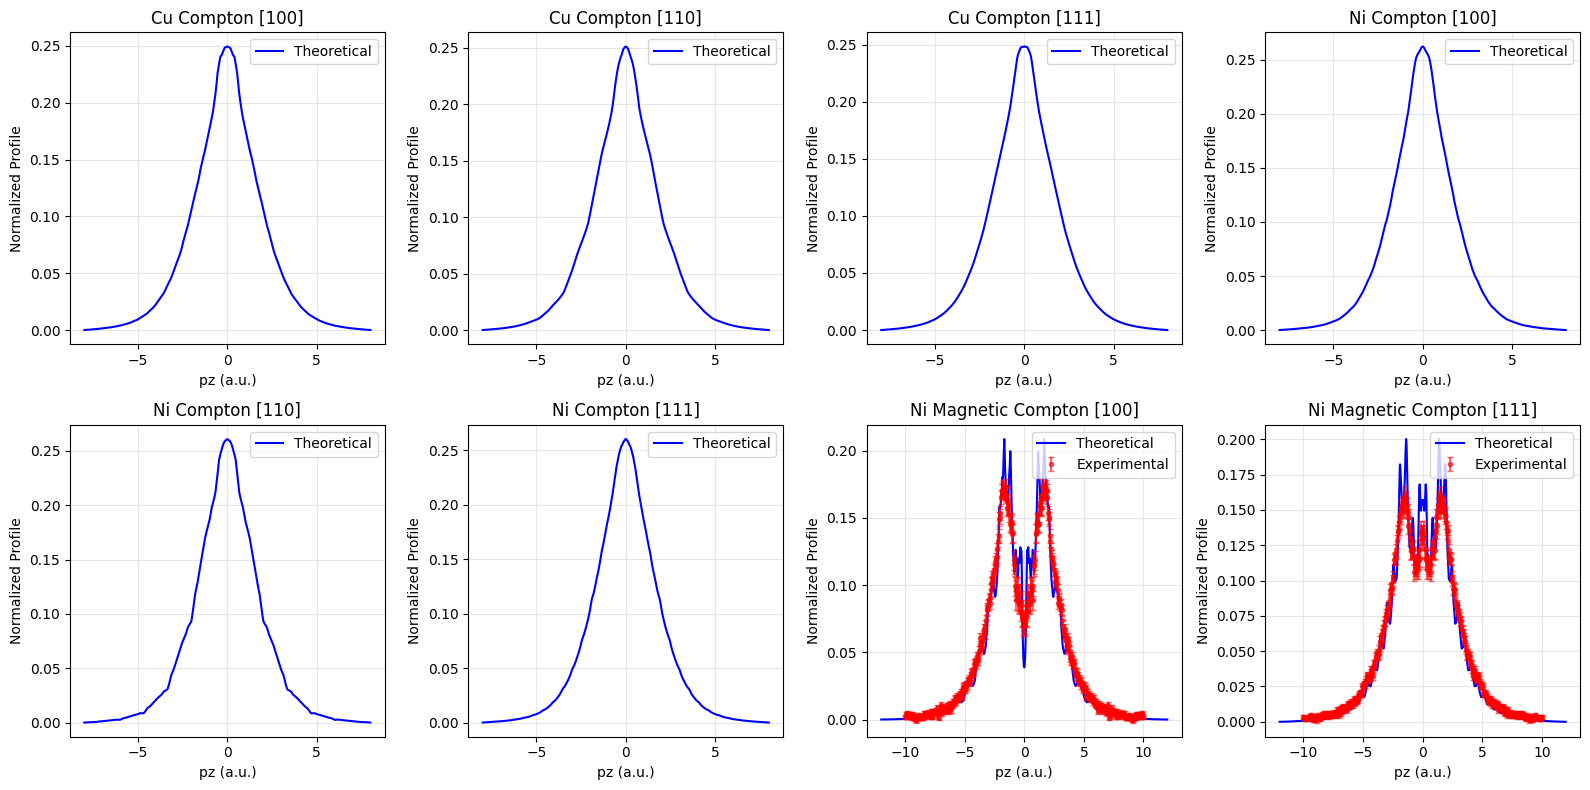

1201
2401
401


In [3]:
# Define base paths
magnetic_data_dir = 'Ni_Magnetic_Compton/'

# Orientations to load
orientations = ['100', '110', '111']

# Initialize 3D nested dictionary structure
df = {
    'Cu_Compton': {},
    'Ni_Compton': {},
    'Ni_Magnetic_Compton': {}
}

# Load Cu_Compton theoretical profiles (non-magnetic, spin-degenerate)
for orientation in orientations:
    cu_file = f'Cu_degen_spin/I_EMD1D.OUT_Cu_{orientation}'
    pz_cu, j_cu = np.loadtxt(cu_file, skiprows=1, unpack=True)
    
    # Normalize the profile
    j_cu_norm = normalise(pz_cu, j_cu)
    
    df['Cu_Compton'][orientation] = {
        'pz': pz_cu,
        'cp': j_cu,  # Compton profile J(pz)
        'cp_norm': j_cu_norm
    }

# Load Ni_Compton theoretical profiles (non-magnetic, spin-degenerate)
for orientation in orientations:
    ni_file = f'Ni_degen_spin/I_EMD1D.OUT_Ni_{orientation}'
    pz_ni, j_ni = np.loadtxt(ni_file, skiprows=1, unpack=True)
    
    # Normalize the profile
    j_ni_norm = normalise(pz_ni, j_ni)
    
    df['Ni_Compton'][orientation] = {
        'pz': pz_ni,
        'cp': j_ni,  # Compton profile J(pz)
        'cp_norm': j_ni_norm
    }

# Load Ni_Magnetic_Compton profiles (spin-resolved)
# Note: Only 100 and 111 orientations have data in Week13
magnetic_orientations = ['100', '111']

for orientation in magnetic_orientations:
    # Read theoretical data (DFT)
    theory_file = f'Ni_Magnetic_Compton/I_EMD1D.OUT.{orientation}'
    pz_theory, j_up, j_down = np.loadtxt(theory_file, skiprows=1, unpack=True)
    
    # Calculate magnetic Compton profile (spin up - spin down)
    mcp_theory = j_up - j_down
    
    # Normalize profiles
    j_up_norm = normalise(pz_theory, j_up)
    j_down_norm = normalise(pz_theory, j_down)
    mcp_theory_norm = normalise(pz_theory, mcp_theory)
    
    # Read experimental data
    exp_file = f'{magnetic_data_dir}ni{orientation}ts_witherrors.dat'
    pz_exp, mcp_exp, error_exp = np.loadtxt(exp_file, unpack=True)
    
    # Normalize experimental profile
    mcp_exp_norm = normalise(pz_exp, mcp_exp)
    error_exp_norm = normalise_error(pz_exp, mcp_exp, error_exp)
    
    df['Ni_Magnetic_Compton'][orientation] = {
        'theoretical': {
            'pz': pz_theory,
            'j_up': j_up,
            'j_down': j_down,
            'j_up_norm': j_up_norm,
            'j_down_norm': j_down_norm,
            'mcp': mcp_theory,
            'mcp_norm': mcp_theory_norm
        },
        'experimental': {
            'pz': pz_exp,
            'mcp': mcp_exp,
            'error': error_exp,
            'mcp_norm': mcp_exp_norm,
            'error_norm': error_exp_norm
        }
    }
    
# Print summary of loaded data - one subplot per (material, orientation) pair
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.flatten()

subplot_idx = 0
for material, orientations_dict in df.items():
    for orientation, data in orientations_dict.items():
        # Check if we're dealing with magnetic Compton (has 'theoretical' key) or regular (direct data)
        if 'theoretical' in data:
            # Ni_Magnetic_Compton case
            pz = data['theoretical']['pz']
            mcp_norm = data['theoretical']['mcp_norm']
            axs[subplot_idx].plot(pz, mcp_norm, label='Theoretical', color='blue')
            
            # Also plot experimental if available
            if 'experimental' in data:
                pz_exp = data['experimental']['pz']
                mcp_exp_norm = data['experimental']['mcp_norm']
                error_exp_norm = data['experimental']['error_norm']
                axs[subplot_idx].errorbar(pz_exp, mcp_exp_norm, yerr=error_exp_norm, 
                                         label='Experimental', color='red', alpha=0.6, 
                                         fmt='o', markersize=3, capsize=2)
        else:
            # Cu_Compton or Ni_Compton case
            pz = data['pz']
            cp_norm = data['cp_norm']
            axs[subplot_idx].plot(pz, cp_norm, label='Theoretical', color='blue')
        
        axs[subplot_idx].set_title(f'{material.replace("_", " ")} [{orientation}]')
        axs[subplot_idx].set_xlabel('pz (a.u.)')
        axs[subplot_idx].set_ylabel('Normalized Profile')
        axs[subplot_idx].legend()
        axs[subplot_idx].grid(True, alpha=0.3)
        
        subplot_idx += 1

plt.tight_layout()
plt.show()

print(len(df['Ni_Compton']['100']['cp_norm']))
print(len(df['Ni_Magnetic_Compton']['100']['theoretical']['mcp_norm']))
print(len(df['Ni_Magnetic_Compton']['100']['experimental']['mcp_norm']))


In [4]:
def gaussian(x, amp, sig):
    return amp * np.exp(-x**2 / (2 * sig**2))

def gauss_model(x, n_gauss, *args):
    arr = np.zeros(x.shape)
    for i in range(n_gauss):
        arr += gaussian(x, *args[i*2:i*2+2])
    return arr

def fourier_series(x, frequency, order=0, f_0 = -.4):
     # Make the parameter objects for all the terms
    a0, *cos_a = parameters(','.join(['a{}'.format(i) for i in range(0, order + 1)]))
    sin_b = parameters(','.join(['b{}'.format(i) for i in range(1, order + 1)]))
    # Construct the series
    series = a0 + sum(ai * cos(i * frequency *f_0 * x) + bi * sin(i * frequency *f_0 * x)
    for i, (ai, bi) in enumerate(zip(cos_a, sin_b), start=1))
    return series


def fit_theoretical_profile(pz, cp, n_gaussians=3, fourier_order=40, fourier_strength=25, initial_guesses=None, verbose=True, fourier_steps=1):
    
    # Set default initial guesses if not provided
    if initial_guesses is None:
        if n_gaussians == 3:
            initial_guesses = [(0.8, 0.5), (0.2, 1.5), (0.1, 3.0)]
        else:
            # Generic initial guess: decreasing amplitudes, increasing widths
            initial_guesses = [((np.max(cp)*0.8) / (i+1), (np.max(cp)*0.5) * (i+1)) for i in range(n_gaussians)]
    
    # Flatten initial guess list
    p0 = [p for prms in initial_guesses for p in prms]
    
    # Define bounds for parameters
    lower_bounds = [0.0, 0.1] * n_gaussians
    upper_bounds = [1.0, 10.0] * n_gaussians
    
    # Create temporary model function for this specific n_gaussians
    def temp_model(x, *args):
        arr = np.zeros(x.shape)
        for i in range(n_gaussians):
            arr += gaussian(x, *args[i*2:i*2+2])
        return arr
    
    # Fit Gaussians using curve_fit
    popt, pcov = curve_fit(temp_model, pz, cp, p0,
                           bounds=(lower_bounds, upper_bounds),
                           method='trf',
                           max_nfev=100000000)
    
    # Reconstruct Gaussian fit
    gauss_fit = np.zeros(cp.shape)
    gauss_params = []
    for i in range(n_gaussians):
        amplitude, sigma = popt[i*2], popt[i*2+1]
        gauss_fit += gaussian(pz, amplitude, sigma)
        gauss_params.append((amplitude, sigma))
        
        if verbose:
            print(f'Gaussian {i+1}: Amplitude = {amplitude:.4f}, Sigma = {sigma:.4f}')
    
    # Calculate residuals
    residuals = cp - gauss_fit
    
    # Fit Fourier series to residuals
    x, y = variables('x, y')
    w, = parameters('w')
    model_dict = {y: fourier_series(x, w, fourier_order, f_0 = 1/fourier_steps)}
    fit = Fit(model_dict, x=pz, y=residuals)
    fit_result = fit.execute()
    
    if verbose:
        print(f'\nFourier Series Fit:')
        print(fit_result)
    
    # Generate Fourier component
    fourier_fit_raw = fit.model(x=pz, **fit_result.params).y
    fourier_fit_scaled = fourier_fit_raw * fourier_strength * gauss_fit
    
    # Complete fit (Gaussian + scaled Fourier)
    complete_fit = gauss_fit + fourier_fit_scaled 
    
    return {
        'gauss_params': gauss_params,
        'gauss_fit': gauss_fit,
        'fourier_params': fit_result.params,
        'fourier_strength': fourier_strength,
        'fourier_fit': fourier_fit_scaled,
        'fourier_fit_raw': fourier_fit_raw,
        'complete_fit': complete_fit,
        'residuals': residuals,
        'popt': popt,
        'pcov': pcov
    }

In [5]:
from Richardson_lucy_functions import gaussian_kernel_1D

def blur(y, res_fwhm, pz_min, pz_max, Npts):
    pz = np.linspace(pz_min, pz_max, Npts)
    grid_spacing = np.abs(pz[1] - pz[0])
    sigma = res_fwhm / (2 * np.sqrt(2 * np.log(2))) / grid_spacing
    size = int(6 * sigma) + 1
    kernel = gaussian_kernel_1D(size, sigma)
    y = signal.convolve(y, kernel, mode='same')
    return y

def noise(y):
    y_noisy = y + np.sqrt(np.abs(y)) * np.random.normal(0,1,size=y.shape)
    return y_noisy

def degrade_compton_profile(y, res_fwhm=0.42, pz_min=-10, pz_max=10, Npts=2401):
    
    y = blur(y, res_fwhm, pz_min, pz_max, Npts)
    y = noise(y)
    return y

Gaussian 1: Amplitude = 0.0000, Sigma = 0.1187
Gaussian 2: Amplitude = 0.1399, Sigma = 2.6806
Gaussian 3: Amplitude = 0.0112, Sigma = 2.6809

Fourier Series Fit:

Parameter Value        Standard Deviation
a0        -1.210986e-03 3.913674e-04
a1        -7.453024e-03 5.647353e-04
a10       -8.467998e-04 5.508718e-04
a11       -2.379368e-04 5.565433e-04
a12       -1.050976e-03 5.816952e-04
a13       -3.694247e-03 5.571803e-04
a14       -7.184618e-04 5.559394e-04
a15       1.035702e-04 5.541270e-04
a16       -2.868471e-05 5.545840e-04
a17       -8.816157e-05 5.520490e-04
a18       2.195719e-04 5.526596e-04
a19       1.204683e-04 5.526127e-04
a2        -1.198942e-02 5.649518e-04
a20       5.836160e-05 5.618748e-04
a21       2.537763e-04 5.530659e-04
a22       1.164669e-04 5.545026e-04
a23       6.939399e-05 5.561772e-04
a24       4.962648e-05 5.565974e-04
a25       1.422809e-04 5.632455e-04
a26       1.086231e-03 5.570883e-04
a27       1.246157e-04 5.522974e-04
a28       6.358363e-05 5.5351

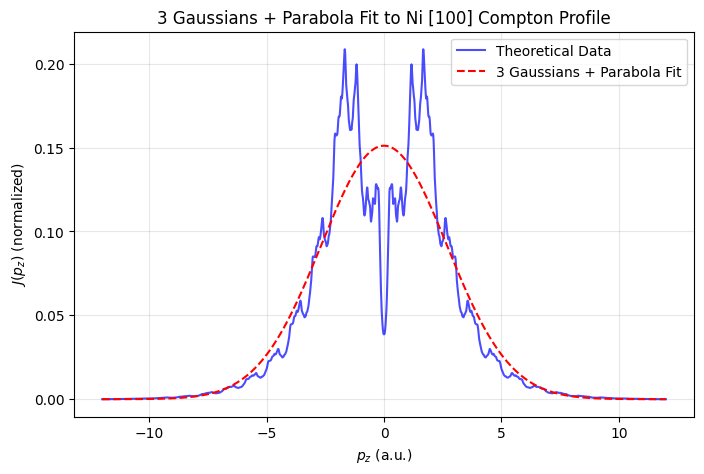

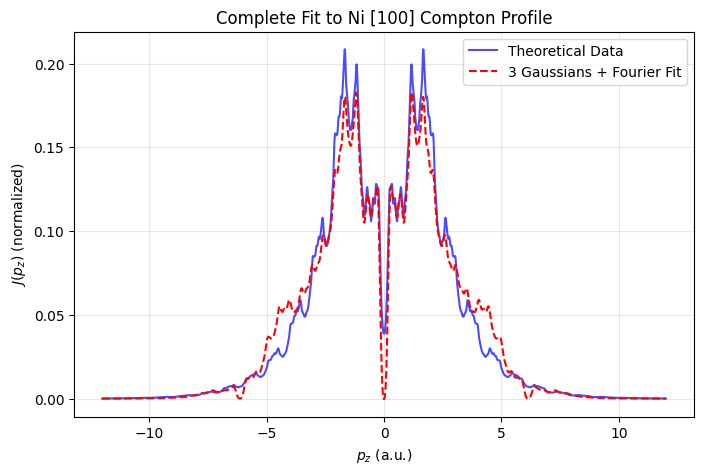

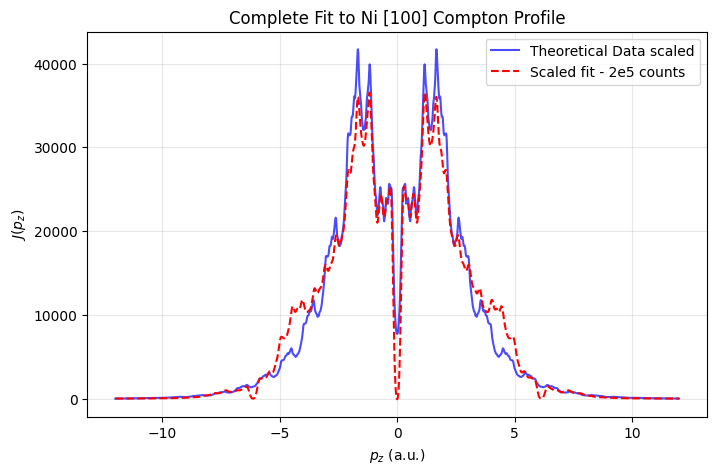

In [ ]:
pz = df['Ni_Magnetic_Compton']['100']['theoretical']['pz']
     df['Ni_Magnetic_Compton']['100']['theoretical']['mcp_norm']

fourier_steps = 1
fourier_order = 35
fourier_strength = 25
# Fit the profile using the fit_theoretical_profile function
fit_result100 = fit_theoretical_profile(pz, cp, n_gaussians=3, fourier_order=fourier_order, fourier_strength=fourier_strength, fourier_steps=1, verbose=True)

# Plot Gaussian-only fit
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pz, cp, label='Theoretical Data', color='blue', alpha=0.7)
ax.plot(pz, fit_result100['gauss_fit'], label='3 Gaussians + Parabola Fit', color='red', linestyle='--')
ax.set_xlabel('$p_z$ (a.u.)')
ax.set_ylabel('$J(p_z)$ (normalized)')
ax.set_title('3 Gaussians + Parabola Fit to Ni [100] Compton Profile')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Plot complete fit with Fourier component
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pz, cp, label='Theoretical Data', color='blue', alpha=0.7)
ax.plot(pz, fit_result100['complete_fit'], label='3 Gaussians + Fourier Fit', color='red', linestyle='--')
ax.set_xlabel('$p_z$ (a.u.)')
ax.set_ylabel('$J(p_z)$ (normalized)')
ax.set_title('Complete Fit to Ni [100] Compton Profile')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

scaled_fit = scale(fit_result100['complete_fit'], t_count)
scaled_profile = scale(cp, t_count)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pz, scaled_profile, label='Theoretical Data scaled', color='blue', alpha=0.7)
ax.plot(pz, scaled_fit, label='Scaled fit - 2e5 counts', color='red', linestyle='--')
ax.set_xlabel('$p_z$ (a.u.)')
ax.set_ylabel('$J(p_z)$')
ax.set_title('Complete Fit to Ni [100] Compton Profile')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


Gaussian 1: Amplitude = 0.0000, Sigma = 0.1094
Gaussian 2: Amplitude = 0.1421, Sigma = 2.5073
Gaussian 3: Amplitude = 0.0165, Sigma = 2.5074

Fourier Series Fit:

Parameter Value        Standard Deviation
a0        1.499888e-04 2.608099e-04
a1        -2.242277e-03 3.699555e-04
a10       1.192123e-04 3.714322e-04
a11       -5.691024e-03 3.687009e-04
a12       4.824196e-04 3.724036e-04
a13       6.623202e-04 3.688424e-04
a14       -1.707905e-04 3.690304e-04
a15       -3.603340e-04 3.689311e-04
a16       6.898417e-05 3.688673e-04
a17       9.757231e-05 3.686996e-04
a18       6.733888e-05 3.687319e-04
a19       9.242784e-05 3.687141e-04
a2        -5.707450e-03 3.691969e-04
a20       7.837860e-05 3.687401e-04
a21       2.874664e-04 3.695130e-04
a22       1.369744e-03 3.687125e-04
a23       6.219735e-05 3.689383e-04
a24       3.158686e-05 3.688332e-04
a25       1.936500e-04 3.687919e-04
a26       9.752308e-05 3.687617e-04
a27       -4.738840e-05 3.687124e-04
a28       6.871601e-07 3.687438e-

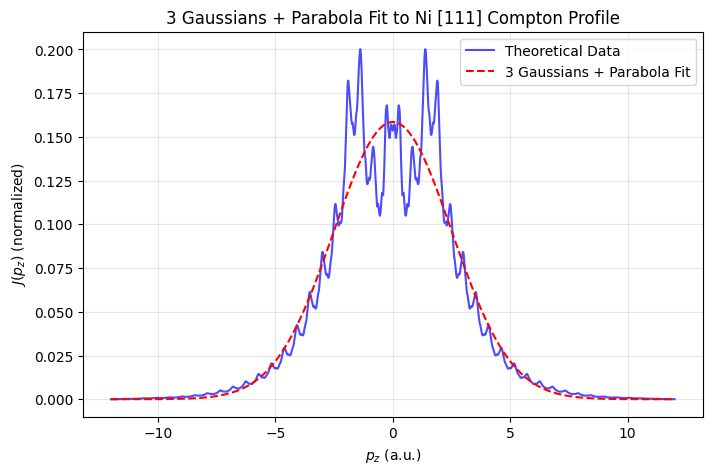

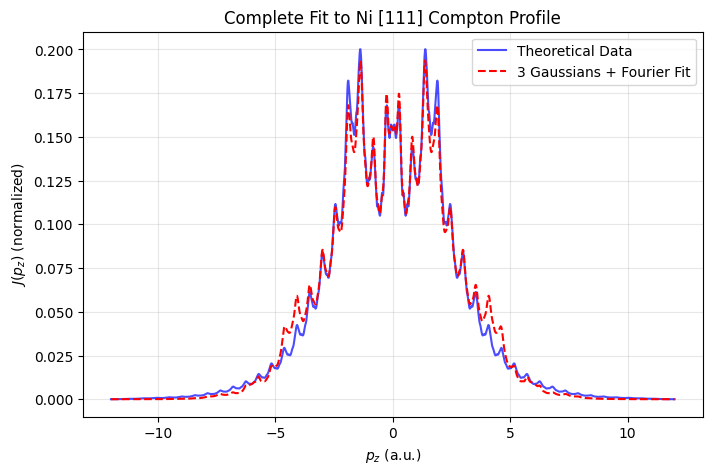

In [7]:
pz = df['Ni_Magnetic_Compton']['111']['theoretical']['pz']
cp = df['Ni_Magnetic_Compton']['111']['theoretical']['mcp_norm']

# Fit the profile using the fit_theoretical_profile function
fit_result111 = fit_theoretical_profile(pz, cp, n_gaussians=3, fourier_order=fourier_order, 
                                     fourier_strength=fourier_strength, verbose=True, fourier_steps=fourier_steps)


# Plot Gaussian-only fit
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pz, cp, label='Theoretical Data', color='blue', alpha=0.7)
ax.plot(pz, fit_result111['gauss_fit'], label='3 Gaussians + Parabola Fit', color='red', linestyle='--')
ax.set_xlabel('$p_z$ (a.u.)')
ax.set_ylabel('$J(p_z)$ (normalized)')
ax.set_title('3 Gaussians + Parabola Fit to Ni [111] Compton Profile')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Plot complete fit with Fourier component
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pz, cp, label='Theoretical Data', color='blue', alpha=0.7)
ax.plot(pz, fit_result111['complete_fit'], label='3 Gaussians + Fourier Fit', color='red', linestyle='--')
ax.set_xlabel('$p_z$ (a.u.)')
ax.set_ylabel('$J(p_z)$ (normalized)')
ax.set_title('Complete Fit to Ni [111] Compton Profile')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [8]:
exp_y = df['Ni_Magnetic_Compton']['100']['experimental']['mcp_norm']
pz_e = df['Ni_Magnetic_Compton']['100']['experimental']['pz']

def GenerateSyntheticProfile(pz, gauss_params, fourier_params, fourier_order=50, f_0=0.4, FWHM=0.42):
    def get_param_value(param):
        return param.value if hasattr(param, 'value') else param

    # Gaussian component
    gauss_profile = np.zeros_like(pz)
    for amplitude, sigma in gauss_params:
        gauss_profile += gaussian(pz, amplitude, sigma)

    # Fourier component
    a0_val = get_param_value(fourier_params['a0'])
    w_val = get_param_value(fourier_params['w'])
    fourier_profile = a0_val * np.ones_like(pz)
    for i in range(1, fourier_order + 1):
        ai_val = get_param_value(fourier_params[f'a{i}'])
        bi_val = get_param_value(fourier_params[f'b{i}'])
        fourier_profile += ai_val * np.cos(i * w_val * f_0 * pz) + bi_val * np.sin(i * w_val * f_0 * pz)

    fourier_profile_scaled = fourier_profile * fit_result100['fourier_strength'] * gauss_profile

    # print('gaussian and fourier profiles:')
    # print(len(gauss_profile), len(fourier_profile))
    # print(len(fourier_profile_scaled))

    # mask = (pz >= pz.min()) & (pz <= pz.max())
    # gauss_profile = gauss_profile[mask][::5]
    # fourier_profile_scaled = fourier_profile_scaled[mask][::5]

    # print('after mask:')
    # print(len(gauss_profile), len(fourier_profile_scaled))

    synthetic_profile = np.array(gauss_profile) + np.array(fourier_profile_scaled)
    if synthetic_profile.min() < 0:
        return None, None

    # print('len pz and syntehtic profile:')
    # print(len(pz), len(synthetic_profile))

    syntetic_norm = normalise(pz, synthetic_profile)
    synthetic_scaled = scale(syntetic_norm, t_count)
   
    try:
        degraded_scaled = degrade_compton_profile(
            synthetic_scaled, FWHM
        )
    except Exception as e:
        print(f"Error generating degraded profile: {e}")
        return None, None

    return synthetic_scaled, degraded_scaled

In [ ]:
# Store all parameters in a pandas dataframe

fit_results_list = [
    {"orientation": "100", **fit_result100},
    {"orientation": "111", **fit_result111}
]
params_df = pd.DataFrame(fit_results_list)


,orientation,gauss_params,gauss_fit,fourier_params,fourier_strength,fourier_fit,fourier_fit_raw,complete_fit,residuals,popt,pcov
0,100,"[(6.65013101136654e-19, 0.11865526038072258), ...","[6.726565260707548e-06, 6.839790198803969e-06,...","{'a0': -0.001210985538657134, 'a1': -0.0074530...",25,"[-1.1524218031113346e-06, -1.1037016160641005e...","[-0.006852958432399806, -0.0064545933953184574...","[5.574143457596213e-06, 5.736088582739868e-06,...","[-6.726552967739088e-06, -6.576304298556449e-0...","[6.65013101136654e-19, 0.11865526038072258, 0....","[[2.6805085687719996e-05, -2.0856039386961546e..."
1,111,"[(2.7937403959098756e-10, 0.10941427250209006)...","[1.6835998529765404e-06, 1.7160315468044577e-0...","{'a0': 0.00014998883411034144, 'a1': -0.002242...",25,"[-4.7162272431817194e-08, -4.785349799795704e-...","[-0.0011205102530375277, -0.001115445647536454...","[1.6364375805447231e-06, 1.6681780488065007e-0...","[-1.6835771045046292e-06, -1.3188054159548389e...","[2.7937403959098756e-10, 0.10941427250209006, ...","[[1.5424345280783962e-05, -2636.5542300580914,..."


In [10]:
fourier_spread = 1.0
gauss_spread = 1.0
N_profiles = 1200
FWHM = 0.42

# Calculate differences in Gaussian parameters between the two profiles
gauss_difference = np.array(params_df.loc[0]['gauss_params']) - np.array(params_df.loc[1]['gauss_params'])

# Calculate differences in Fourier parameters between the two profiles
fourier_0 = params_df.loc[0]['fourier_params']
fourier_1 = params_df.loc[1]['fourier_params']
odd_sucess = 0
even_sucess = 0
fourier_difference = {}
for param_name in fourier_0.keys():
    diff = fourier_0[param_name] - fourier_1[param_name]
    fourier_difference[param_name] = diff

# Generate N_profiles synthetic profiles with randomized parameters
clean_profiles = []
degraded_profiles = []
attempts = 0
max_attempts = N_profiles * 10  # Prevent infinite loop

while len(clean_profiles) < N_profiles and attempts < max_attempts:
    attempts += 1
    
    # Create test Gaussian parameters by randomly varying the original parameters
    test_gauss_params = []
    for i in range(3):
        amp_diff = gauss_difference[i][0]
        sigma_diff = gauss_difference[i][1]
        
        # Randomly vary the parameters within a certain spread
        amp_variation = random.uniform(-gauss_spread, gauss_spread) * amp_diff * fourier_spread
        sigma_variation = random.uniform(-gauss_spread, gauss_spread) * sigma_diff * fourier_spread
        
        if attempts % 2 == 0:
            test_amp = params_df.loc[0]['gauss_params'][i][0] + amp_variation
            test_sigma = params_df.loc[0]['gauss_params'][i][1] + sigma_variation
        else:
            test_amp = params_df.loc[1]['gauss_params'][i][0] + amp_variation
            test_sigma = params_df.loc[1]['gauss_params'][i][1] + sigma_variation
        
        test_gauss_params.append((test_amp, test_sigma))
    
    # Create test Fourier parameters by randomly varying the original parameters
    test_fourier_params = {}
    if attempts % 2 == 0:
        fourier_base = fourier_0
    else:
        fourier_base = fourier_1
    for param_name in fourier_base.keys():
        original_value = fourier_base[param_name]
        diff = fourier_difference[param_name]
        
        # Randomly vary the parameter within a certain spread
        variation = random.uniform(-fourier_spread, fourier_spread) * diff * fourier_spread
        test_fourier_params[param_name] = original_value + variation
    
    # Generate the synthetic profile
     #+ random.uniform(-noise_variation, noise_variation)
    #print(noise)
    test_profile, degraded_profile = GenerateSyntheticProfile(pz, test_gauss_params, test_fourier_params, fourier_order=fourier_order, f_0=1/fourier_steps, FWHM = FWHM)
    if test_profile is not None and degraded_profile is not None:
        clean_profiles.append(test_profile)
        degraded_profiles.append(degraded_profile)
        if attempts % 2 == 0:
            even_sucess += 1
        else:
            odd_sucess += 1
print("Even attempts successful:", even_sucess)
print("Odd attempts successful:", odd_sucess)
print(f"Generated {len(clean_profiles)} valid synthetic profiles (out of {attempts} attempts)")


Even attempts successful: 384
Odd attempts successful: 816
Generated 1200 valid synthetic profiles (out of 1631 attempts)


ValueError: x and y must have same first dimension, but have shapes (401,) and (2401,)

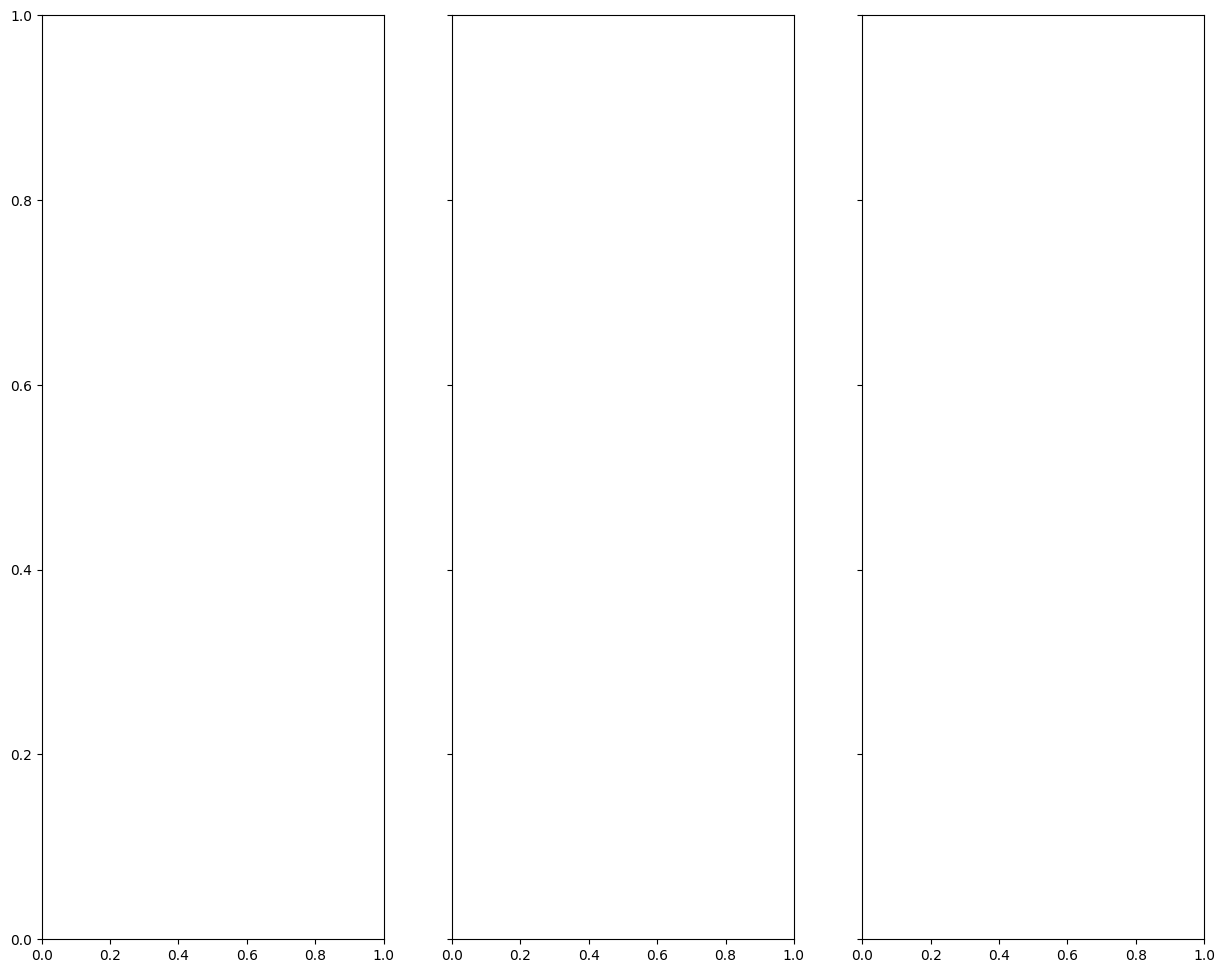

In [94]:
fig, axs = plt.subplots(1, 3, figsize=(15, 12), sharex=True, sharey=True)
axs = axs.flatten()

# Display up to 3 profiles
n_display = min(3, len(clean_profiles))

for i in range(n_display):
    test_profile = clean_profiles[i]
    axs[i].plot(pz, clean_profiles[i], linewidth=1.5)
    axs[i].plot(pz, degraded_profiles[i], linewidth=1.5, alpha=0.7)
    axs[i].set_title(f'Clean Profile {i+1}')
    axs[i].set_xlabel('$p_z$ (a.u.)')
    axs[i].set_ylabel('j(p_z)')
    axs[i].grid(True, alpha=0.3)
    axs[i].set_xlim(pz_e.min(), pz_e.max())

plt.tight_layout()
plt.show()

print(len(clean_profiles[1]))
print(len(degraded_profiles[1]))

In [12]:
print(len(pz))
print(pz.max(), pz.min())

print(len(pz_e))
print(pz_e.max(), pz_e.min())


2401
12.0 -12.0
401
10.0 -10.0


## CNN with skip connections

Disused

In [13]:
from models_and_training_functions import train_model, visualise_training, validate_and_visualise
from sklearn.model_selection import train_test_split

class DeblurUnet(nn.Module):
    def __init__(self):
        super(DeblurUnet, self).__init__()
        
        self.enc1 = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.ReLU(),)
        
        self.enc2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.enc3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.dec1 = nn.Sequential(
            nn.Conv1d(256, 128, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.dec2 = nn.Sequential(
            nn.Conv1d(256, 64, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.dec3 = nn.Sequential(
            nn.Conv1d(128, 64, kernel_size=5, padding=2),
            nn.ReLU(),)

        self.final = nn.Conv1d(64, 1, kernel_size=7, padding=3)        
    
    def forward(self, x):
        x_input = x.unsqueeze(1)
        e1 = self.enc1(x_input)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        d1 = self.dec1(e3)
        d2 = self.dec2(torch.cat([d1, e2], dim=1))
        d3 = self.dec3(torch.cat([d2, e1], dim=1))
        output = self.final(d3)
        output = output.squeeze(1)
        output = x + 0.1 * output
        return output
    
    

In [14]:
test_size = 0.1
seed = 42

X = np.stack(degraded_profiles)  # Degraded profiles (inputs)    
y = np.stack(clean_profiles)     # Clean profiles (targets)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

In [187]:
from scipy.ndimage import uniform_filter1d

def gradient_loss_1d(pred, target):
    """
    Calculates the Mean Squared Error (MSE) of the first derivatives.
    This forces the model to match the slopes and inflection points (the double peak).
    """
    # np.diff calculates the step-by-step differences (gradients) along the array
    pred_grad = np.diff(pred, axis=-1)
    target_grad = np.diff(target, axis=-1)
    
    return np.mean((pred_grad - target_grad) ** 2)

def combined_loss(pred, target, alpha=1, beta=1, window_size=7):
    
    # SSIM returns 1 for a perfect match, so we subtract from 1 for the loss
    d_range = target.max() - target.min()
    ssim_val = ssim(pred, target, data_range = d_range)
    ssim_loss = 1.0 - ssim_val
    
    # Calculate gradient loss
    grad_loss = gradient_loss_1d(pred, target)
    
    # Compute total weighted loss
    total_loss = (alpha * ssim_loss) + (beta * grad_loss)
    
    return total_loss

In [161]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=1000, batch_size=32, lr=0.001):
    
    # ability to vary the loss function:
    criterion = nn.MSELoss()
    #criterion = combined_loss

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=50, factor=0.5)

    train_losses = []
    test_losses = []
    
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * inputs.size(0)

        avg_train_loss = epoch_loss / len(X_train)
        train_losses.append(avg_train_loss)
        
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test).item()
            test_losses.append(test_loss)
        
        if (epoch+1) % 1 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.7f}, Test Loss: {test_loss:.7f}')
    
    return train_losses, test_losses


# Function to visualise training progress
def visualise_training(train_losses, test_losses):

    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('MSE Loss', fontsize=12)
    plt.yscale('log')
    plt.title('Training and Test Loss Over Time', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nFinal Training Loss: {train_losses[-1]:.6f}")
    print(f"Final Test Loss: {test_losses[-1]:.6f}")


Epoch [1/100], Train Loss: 3812211.5685185, Test Loss: 3835364.5000000
Epoch [2/100], Train Loss: 3784361.5796296, Test Loss: 3724463.2500000
Epoch [3/100], Train Loss: 3225516.0962963, Test Loss: 2483141.0000000
Epoch [4/100], Train Loss: 2226393.7370370, Test Loss: 2201477.0000000
Epoch [5/100], Train Loss: 2101224.5351852, Test Loss: 2121223.7500000
Epoch [6/100], Train Loss: 2033951.4370370, Test Loss: 2051260.2500000
Epoch [7/100], Train Loss: 1979802.0666667, Test Loss: 2018769.5000000
Epoch [8/100], Train Loss: 1959739.6796296, Test Loss: 2007688.0000000
Epoch [9/100], Train Loss: 1953260.2564815, Test Loss: 2012567.1250000
Epoch [10/100], Train Loss: 1945236.8518519, Test Loss: 1994777.8750000
Epoch [11/100], Train Loss: 1947538.4037037, Test Loss: 2005787.8750000
Epoch [12/100], Train Loss: 1944502.9287037, Test Loss: 1989594.8750000
Epoch [13/100], Train Loss: 1942815.0750000, Test Loss: 1986943.1250000
Epoch [14/100], Train Loss: 1935094.5675926, Test Loss: 1986465.0000000
E

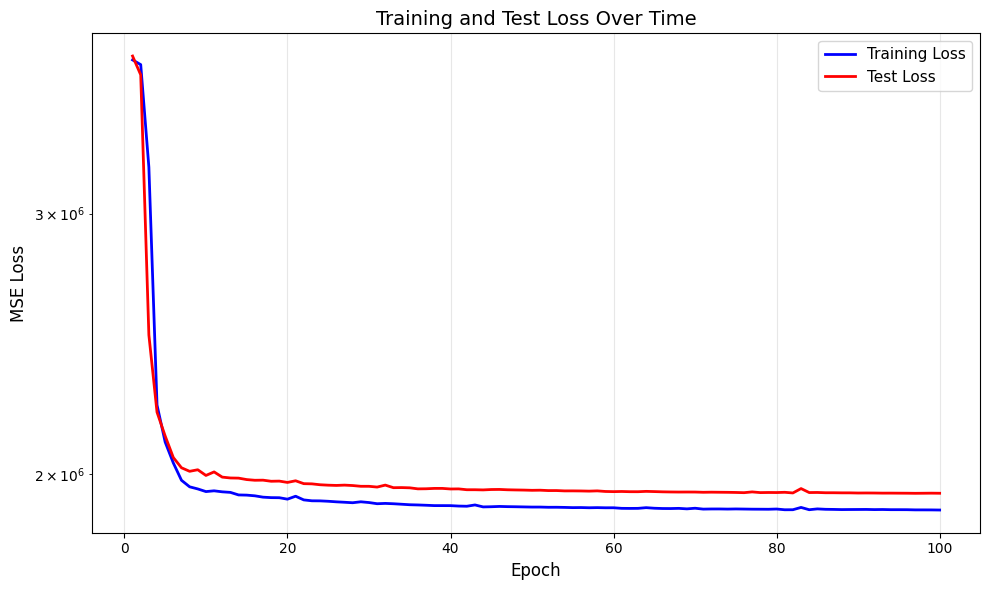


Final Training Loss: 1890117.269444
Final Test Loss: 1940160.875000


In [16]:
model = DeblurUnet()

train_losses, test_losses = train_model(model=model,X_train=X_train,y_train=y_train, X_test=X_test,
                                         y_test=y_test, epochs=100, batch_size=32, lr=0.0001)

visualise_training(train_losses, test_losses)



TEST SET EVALUATION
Number of test samples: 120
Average MSE: 1940160.750000
Average MAE: 690.181641
Std MSE: 973779.937500
Min MSE: 465100.250000
Max MSE: 4411838.000000


ValueError: x and y must have same first dimension, but have shapes (401,) and (2401,)

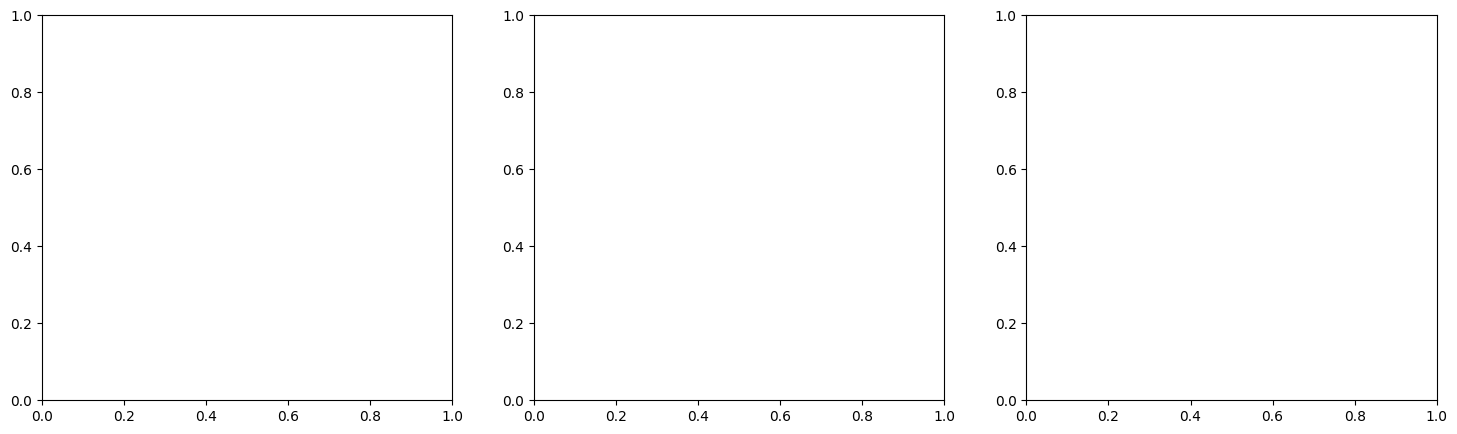

In [18]:
# Evaluate on test set
model.eval()

with torch.no_grad():
    # Get predictions for all test samples
    test_predictions = model(X_test).numpy()
    test_clean = y_test.numpy()
    test_degraded = X_test.numpy()
    
    # Calculate metrics
    mse_per_sample = np.mean((test_predictions - test_clean)**2, axis=1)
    mae_per_sample = np.mean(np.abs(test_predictions - test_clean), axis=1)
    
    print("\n" + "=" * 60)
    print("TEST SET EVALUATION")
    print("=" * 60)
    print(f"Number of test samples: {len(test_predictions)}")
    print(f"Average MSE: {np.mean(mse_per_sample):.6f}")
    print(f"Average MAE: {np.mean(mae_per_sample):.6f}")
    print(f"Std MSE: {np.std(mse_per_sample):.6f}")
    print(f"Min MSE: {np.min(mse_per_sample):.6f}")
    print(f"Max MSE: {np.max(mse_per_sample):.6f}")
    print("=" * 60)

# Plot 9 examples from test set
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
axs = axs.flatten()

n_display = min(3, len(test_predictions))
display_indices = np.linspace(0, len(test_predictions)-1, n_display, dtype=int)

for i, idx in enumerate(display_indices):
    ax = axs[i]
    
    ax.plot(pz_e, test_clean[idx], 'g-', label='Clean (Ground Truth)', 
            linewidth=2, alpha=0.8)
    ax.plot(pz_e, test_degraded[idx], 'r--', label='Degraded Input', 
            linewidth=1.5, alpha=0.7)
    ax.plot(pz_e, test_predictions[idx], 'b-', label='CNN Deconvolved', 
            linewidth=2, alpha=0.8)
    
    ax.set_title(f'Test Sample {idx+1} | MSE: {mse_per_sample[idx]:.6f}', 
                fontsize=11)
    ax.set_xlabel('$p_z$ (a.u.)', fontsize=10)
    ax.set_ylabel('j(p_z)', fontsize=10)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

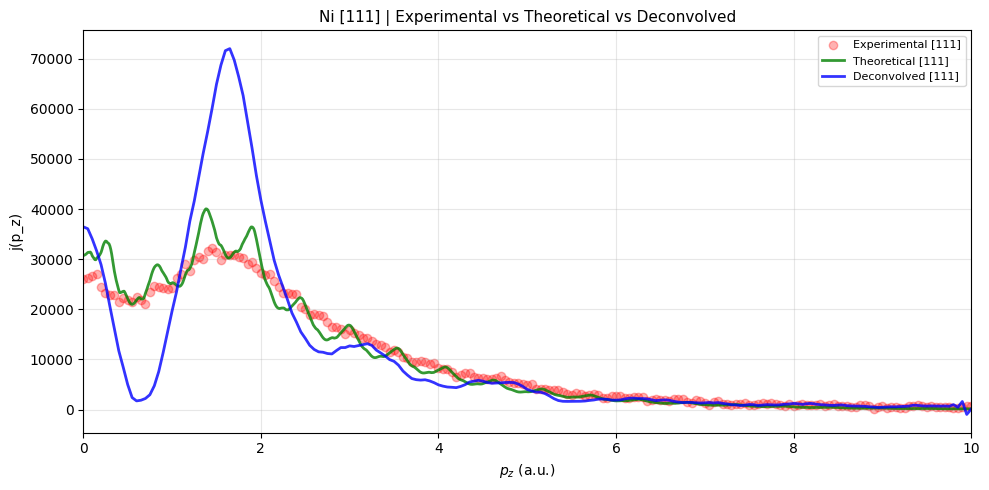

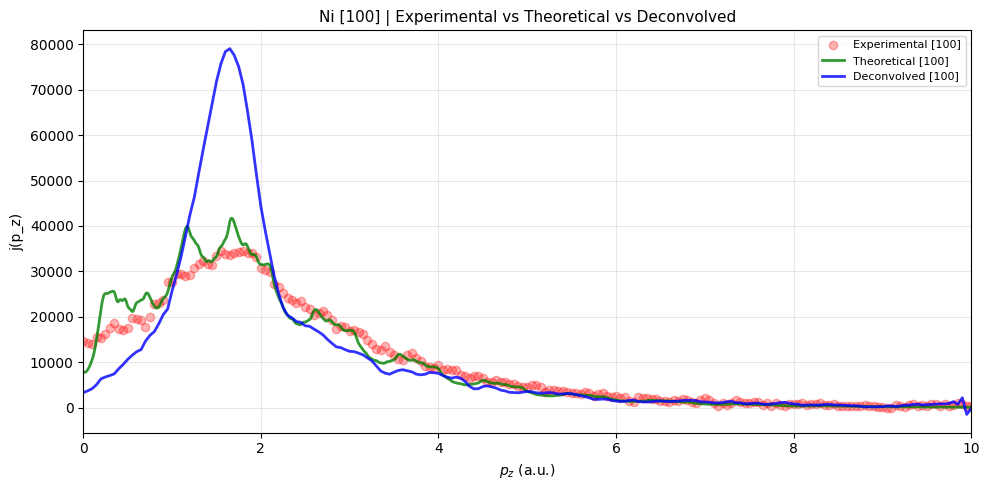

In [19]:
experimental111 = df['Ni_Magnetic_Compton']['111']['experimental']['mcp_norm']
theoretical111 = df['Ni_Magnetic_Compton']['111']['theoretical']['mcp_norm']
pz_t = df['Ni_Magnetic_Compton']['111']['theoretical']['pz']

# normalise experimental111 and theoretical111 between 0 and 1
#experimental111 = (experimental111 - theoretical111.min()) / (theoretical111.max() - theoretical111.min()) 
# normalise experimental111 by area
experimental111 = normalise(pz_e, experimental111)
experimental111 = scale(experimental111, t_count)
theoretical111 = normalise(pz_t, theoretical111)
theoretical111 = scale(theoretical111, t_count)

# convert to tensors
experimental111 = torch.FloatTensor(experimental111)
theoretical111 = torch.FloatTensor(theoretical111)

model.eval()
with torch.no_grad():
    deconvolved111 = model(experimental111.unsqueeze(0)).squeeze(0)


pz_t = df['Ni_Magnetic_Compton']['111']['theoretical']['pz']
pz_e = df['Ni_Magnetic_Compton']['111']['experimental']['pz']

fig, ax = plt.subplots(figsize = (10,5))
ax.scatter(pz_e, experimental111, c = 'r', label='Experimental [111]', alpha=0.3)
ax.plot(pz_t, theoretical111, 'g-', label='Theoretical [111]', linewidth=2, alpha=0.8)
ax.plot(pz_e, deconvolved111.detach().numpy(), 'b-', label='Deconvolved [111]', linewidth=2, alpha=0.8)
ax.set_title('Ni [111] | Experimental vs Theoretical vs Deconvolved', fontsize=11)
ax.set_xlabel('$p_z$ (a.u.)', fontsize=10)
ax.set_ylabel('j(p_z)', fontsize=10)
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, pz_e.max())
fig.tight_layout()
fig.savefig('Ni_111_Deconvolution.png', dpi=300)

experimental100 = df['Ni_Magnetic_Compton']['100']['experimental']['mcp_norm']
theoretical100 = df['Ni_Magnetic_Compton']['100']['theoretical']['mcp_norm']

# normalise experimental100 and theoretical100 to have area 0
experimental100 = normalise(pz_e, experimental100)
experimental100 = scale(experimental100, t_count)
theoretical100 = normalise(pz_t, theoretical100)
theoretical100 = scale(theoretical100, t_count)

# convert to tensors
experimental100 = torch.FloatTensor(experimental100)
theoretical100 = torch.FloatTensor(theoretical100)

pz_t = df['Ni_Magnetic_Compton']['100']['theoretical']['pz']
pz_e = df['Ni_Magnetic_Compton']['100']['experimental']['pz']
deconvolved100 = model(torch.FloatTensor(experimental100).unsqueeze(0)).squeeze(0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pz_e, experimental100, c = 'r', label='Experimental [100]', alpha=0.3)
ax.plot(pz_t, theoretical100, 'g-', label='Theoretical [100]', linewidth=2, alpha=0.8)
ax.plot(pz_e, deconvolved100.detach().numpy(), 'b-', label='Deconvolved [100]', linewidth=2, alpha=0.8)
ax.set_title('Ni [100] | Experimental vs Theoretical vs Deconvolved', fontsize=11)
ax.set_xlabel('$p_z$ (a.u.)', fontsize=10)
ax.set_ylabel('j(p_z)', fontsize=10)
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, pz_e.max())
fig.tight_layout()
fig.savefig('Ni_100_Deconvolution.png', dpi=300)

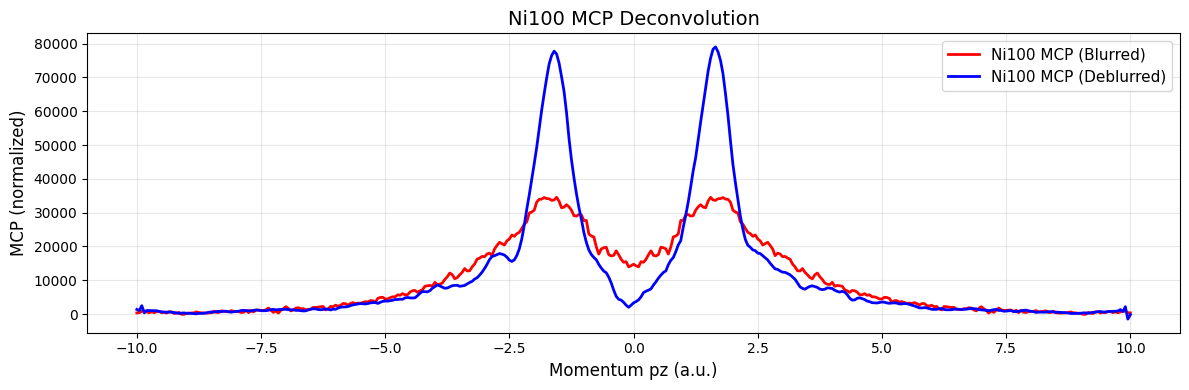

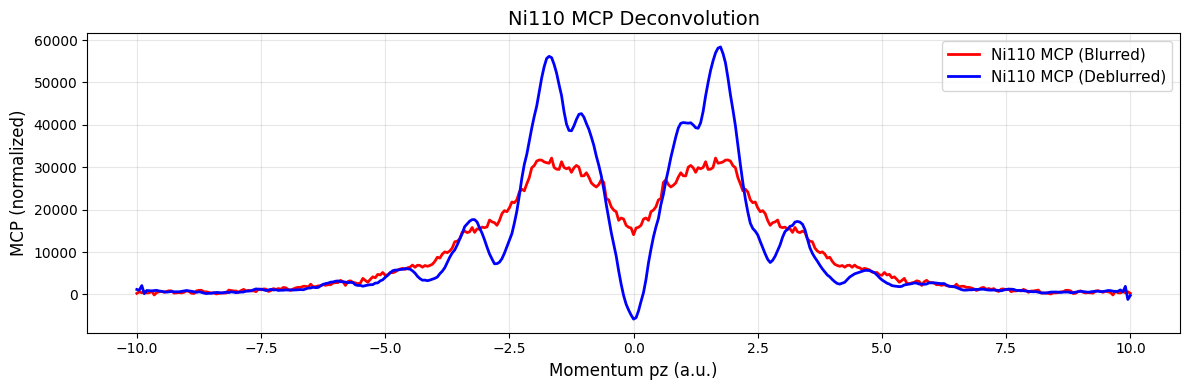

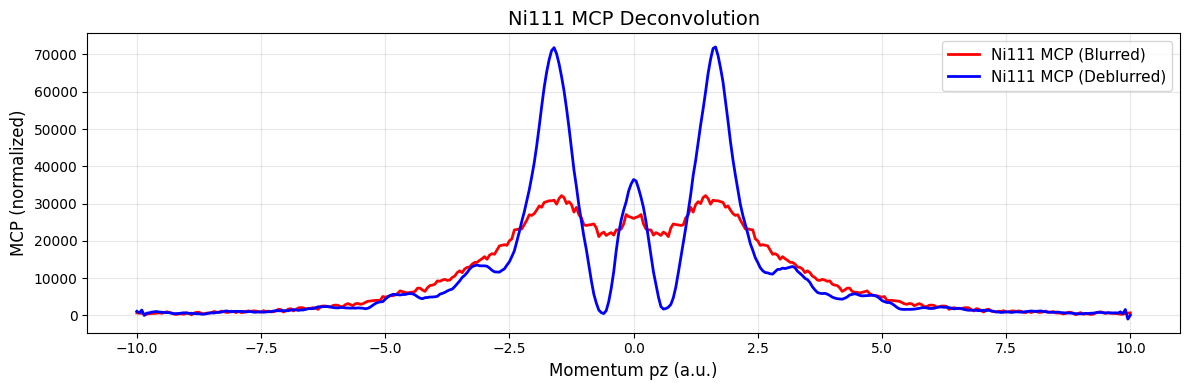

In [20]:
ni100 = np.loadtxt('Ni_Magnetic_Compton/ni100ts_witherrors.dat')
ni110 = np.loadtxt('Ni_Magnetic_Compton/ni110ts_witherrors.dat')
ni111 = np.loadtxt('Ni_Magnetic_Compton/ni111ts_witherrors.dat')

pz = ni100[:,0]
mcp100 = ni100[:,1]
mcp110 = ni110[:,1]
mcp111 = ni111[:,1]

mcp100 = normalise(pz, mcp100)
mcp110 = normalise(pz, mcp110)
mcp111 = normalise(pz, mcp111)

mcp100 = scale(mcp100, t_count)
mcp110 = scale(mcp110, t_count)
mcp111 = scale(mcp111, t_count)

blur_tensors_100 = torch.FloatTensor(mcp100).unsqueeze(0)
blur_tensors_110 = torch.FloatTensor(mcp110).unsqueeze(0)
blur_tensors_111 = torch.FloatTensor(mcp111).unsqueeze(0)

model.eval()
with torch.no_grad():
    deblurred_100 = model(blur_tensors_100).squeeze(0).numpy()
    deblurred_110 = model(blur_tensors_110).squeeze(0).numpy()
    deblurred_111 = model(blur_tensors_111).squeeze(0).numpy()


for i in range(3):
    plt.figure(figsize=(12, 4))
    if i == 0:
        plt.plot(pz, mcp100, 'r', label='Ni100 MCP (Blurred)', linewidth=2)
        plt.plot(pz, deblurred_100, 'b-', label='Ni100 MCP (Deblurred)', linewidth=2)
        plt.title('Ni100 MCP Deconvolution', fontsize=14)
    elif i == 1:
        plt.plot(pz, mcp110, 'r', label='Ni110 MCP (Blurred)', linewidth=2)
        plt.plot(pz, deblurred_110, 'b-', label='Ni110 MCP (Deblurred)', linewidth=2)
        plt.title('Ni110 MCP Deconvolution', fontsize=14)
    else:
        plt.plot(pz, mcp111, 'r', label='Ni111 MCP (Blurred)', linewidth=2)
        plt.plot(pz, deblurred_111, 'b-', label='Ni111 MCP (Deblurred)', linewidth=2)
        plt.title('Ni111 MCP Deconvolution', fontsize=14)

    plt.xlabel('Momentum pz (a.u.)', fontsize=12)
    plt.ylabel('MCP (normalized)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Benchmarking

Setting a universal benchmark for all models to be compared against. Uses theoretical Compton profiles and MCPs in [100] direction

C:\Users\Jpjha\AppData\Local\Temp\ipykernel_9792\1931484791.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


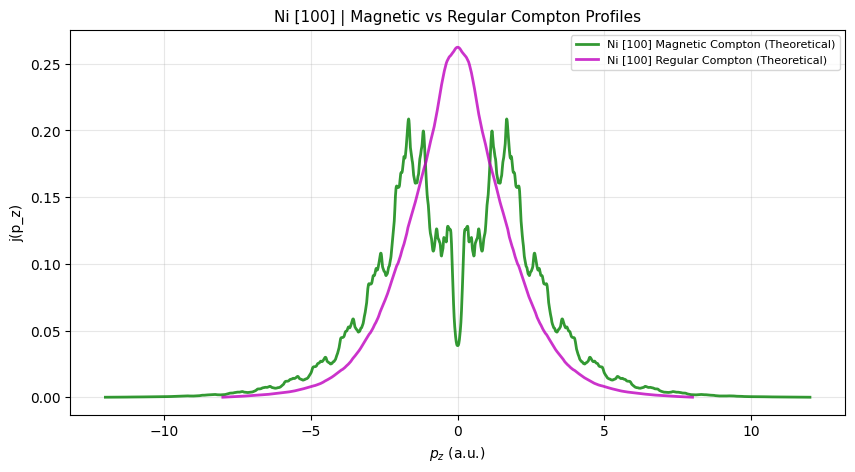

In [173]:
pz_mcp = df['Ni_Magnetic_Compton']['100']['theoretical']['pz']
theoretical100_mcp = df['Ni_Magnetic_Compton']['100']['theoretical']['mcp_norm']
theoretical111_mcp = df['Ni_Magnetic_Compton']['111']['theoretical']['mcp_norm']
pz_cp = df['Ni_Compton']['100']['pz']
theoretical100_Jpz = df['Ni_Compton']['100']['cp_norm']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pz_mcp, theoretical100_mcp, 'g-', label='Ni [100] Magnetic Compton (Theoretical)', linewidth=2, alpha=0.8)
ax.plot(pz_cp, theoretical100_Jpz, 'm-', label='Ni [100] Regular Compton (Theoretical)', linewidth=2, alpha=0.8)
ax.set_title('Ni [100] | Magnetic vs Regular Compton Profiles', fontsize=11)
ax.set_xlabel('$p_z$ (a.u.)', fontsize=10)
ax.set_ylabel('j(p_z)', fontsize=10)
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)
fig.show()


2401
-12.0 12.0


C:\Users\Jpjha\AppData\Local\Temp\ipykernel_9792\3684977521.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


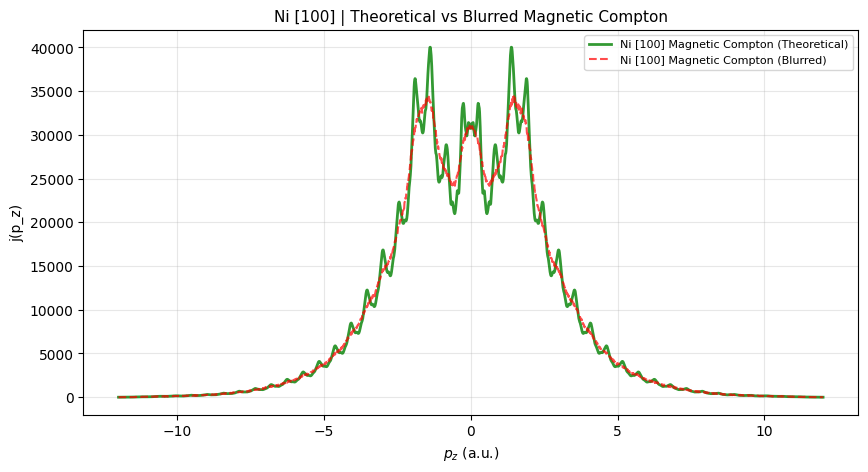

In [174]:
mcp_scaled_100 = scale(theoretical100_mcp, t_count)
blur_mcp_100 = degrade_compton_profile(mcp_scaled_100, res_fwhm=0.42, pz_min=pz_mcp.min(), pz_max=pz_mcp.max(), Npts=len(pz_mcp))
mcp_scaled_111 = scale(theoretical111_mcp, t_count)
blur_mcp_111 = degrade_compton_profile(mcp_scaled_111, res_fwhm=0.42, pz_min=pz_mcp.min(), pz_max=pz_mcp.max(), Npts=len(pz_mcp))


print(len(pz_mcp))
print(pz_mcp.min(), pz_mcp.max())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pz_mcp, mcp_scaled, 'g-', label='Ni [100] Magnetic Compton (Theoretical)', linewidth=2, alpha=0.8)
ax.plot(pz_mcp, blur_mcp, 'r--', label='Ni [100] Magnetic Compton (Blurred)', linewidth=1.5, alpha=0.7)
ax.set_title('Ni [100] | Theoretical vs Blurred Magnetic Compton', fontsize=11)
ax.set_xlabel('$p_z$ (a.u.)', fontsize=10)
ax.set_ylabel('j(p_z)', fontsize=10)
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)
fig.show()


C:\Users\Jpjha\AppData\Local\Temp\ipykernel_9792\22238486.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


(2401,)
(2401,)


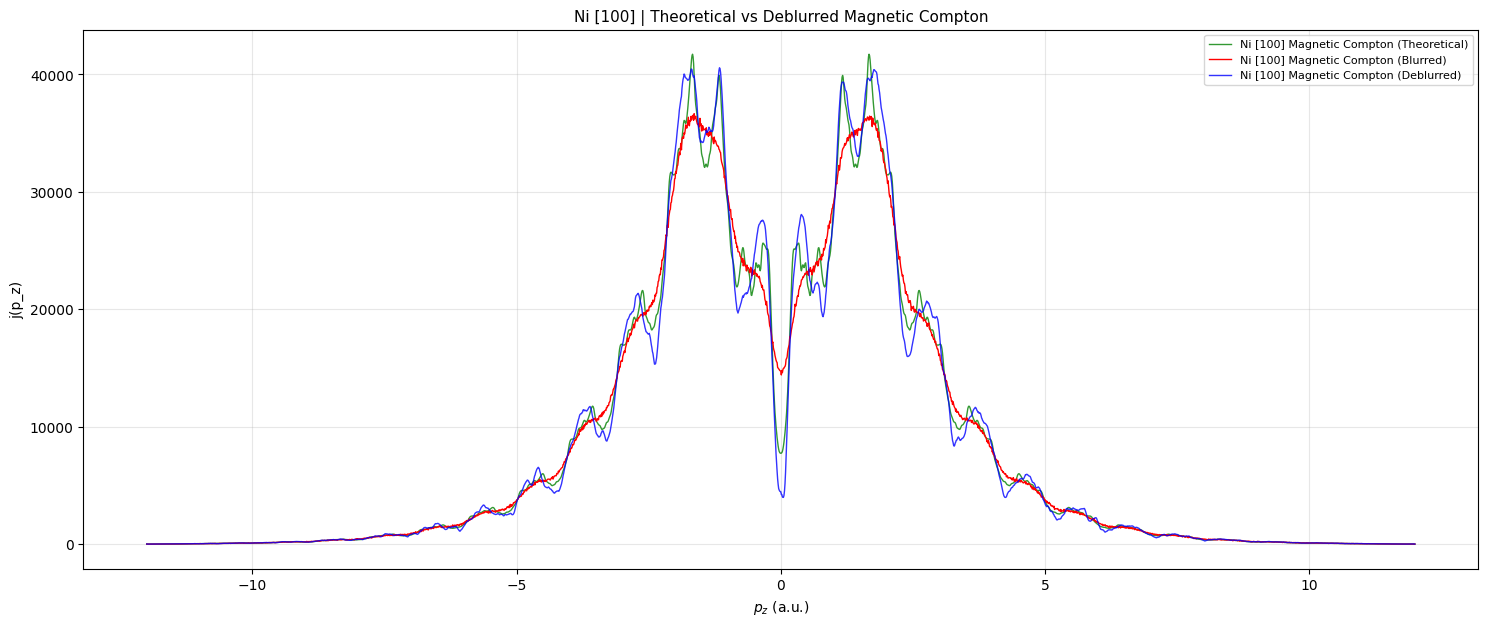

In [ ]:
blur_mcp_tensor_100 = torch.FloatTensor(blur_mcp_100).unsqueeze(0)

model.eval()
with torch.no_grad():
    deblurred_mcp = model(blur_mcp_tensor_100).squeeze(0).numpy()

fig, ax = plt.subplots(figsize=(18, 7))
ax.plot(pz_mcp, mcp_scaled_100, 'g-', label='Ni [100] Magnetic Compton (Theoretical)', linewidth=1, alpha=0.8)
ax.plot(pz_mcp, blur_mcp_100, 'r-', label='Ni [100] Magnetic Compton (Blurred)', linewidth=1, alpha=1)
ax.plot(pz_mcp, deblurred_mcp_100, 'b-', label='Ni [100] Magnetic Compton (Deblurred)', linewidth=1, alpha=0.8)
ax.set_title('Ni [100] | Theoretical vs Deblurred Magnetic Compton', fontsize=11)
ax.set_xlabel('$p_z$ (a.u.)', fontsize=10)
ax.set_ylabel('j(p_z)', fontsize=10)
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)
fig.show()

print(deblurred_mcp.shape)
print(pz_mcp.shape)



In [ ]:
import numpy as np
from skimage.metrics import structural_similarity as ssim

def calculate_signal_metrics(theoretical, deblurred, sigma=None):

    if sigma is None:
        sigma = 1.0
    
    residuals = deblurred - theoretical
    chi_sq = np.sum((residuals / sigma)**2)
    reduced_chi_sq = chi_sq / len(theoretical)
    
    d_range = theoretical.max() - theoretical.min()
    score_ssim = ssim(theoretical, deblurred, data_range=d_range)
    
    return reduced_chi_sq, score_ssim


error_estimate = np.sqrt(mcp_scaled)
red_chi, ssim_val = calculate_signal_metrics(mcp_scaled, deblurred_mcp, sigma=error_estimate)

print(f"Reduced Chi-Squared: {red_chi:.4f}")
print(f"SSIM: {ssim_val:.4f}")

Reduced Chi-Squared: 12884.7474
SSIM: 0.9583


# optimisation and tuning

redefine the model to make it actually a U-net


# U-net

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(Conv1d => BatchNorm1d => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool1d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv, with dimension matching for odd sizes like 2401"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Transposed convolution for upsampling
        self.up = nn.ConvTranspose1d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        
        # Grab specifically the 3rd dimension (Length) at index 2
        diff = x2.size(2) - x1.size(2) 
        
        # Pad the upsampled tensor to match the skip connection (x2)
        x1 = F.pad(x1, [diff // 2, diff - diff // 2])
        
        # Concatenate skip connection
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class AdaptedDeblurUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(AdaptedDeblurUNet, self).__init__()
        
        # Encoder (Downsampling)
        self.inc = DoubleConv(in_channels, 32)
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        
        # Decoder (Upsampling)
        self.up1 = Up(256, 128)
        self.up2 = Up(128, 64)
        self.up3 = Up(64, 32)
        
        # Final convolution to map back to 1 channel
        self.outc = nn.Conv1d(32, out_channels, kernel_size=1)

    def forward(self, x):
        # 1. SAVE the original input safely so it doesn't get overwritten!
        original_x = x 
        
        # Ensure correct shape: (Batch, Channels, Length)
        if x.dim() == 2:
            x_input = x.unsqueeze(1)
        else:
            x_input = x
            
        # Encoder Pathway
        x1 = self.inc(x_input)      # Output: (B, 32, 2401)
        x2 = self.down1(x1)         # Output: (B, 64, 1200)
        x3 = self.down2(x2)         # Output: (B, 128, 600)
        x4 = self.down3(x3)         # Output: (B, 256, 300) - Bottleneck
        
        # Decoder Pathway (Use 'd' instead of 'x' to prevent overwriting!)
        d = self.up1(x4, x3)        # Output: (B, 128, 600)
        d = self.up2(d, x2)         # Output: (B, 64, 1200)
        d = self.up3(d, x1)         # Output: (B, 32, 2401)
        
        residual = self.outc(d)     # Output: (B, 1, 2401)
        
        # Squeeze back to (Batch, Length)
        residual = residual.squeeze(1)
        
        # Global residual connection: The network learns the correction (deblurring step)
        output = original_x + residual 
        
        return output

In [82]:
import optuna
import torch.optim as optim
import torch.nn as nn

def objective(trial, model, max_epochs):
    # --- Hyperparameter Search Space ---
    lr = trial.suggest_float("lr", 1e-3, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-4, log=True)
    
    # --- Model Setup ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = getattr(optim, optimizer_name)(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # --- Early Stopping Setup ---
    early_stopping = EarlyStopping(patience=15, min_delta=1e-5) 
    
    for epoch in range(max_epochs):
        # -- Training --
        model.train()
        for batch_x, batch_y in train_loader: 
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
        # -- Validation --
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()
                
        val_loss /= len(test_loader)
        
        # Report to Optuna to prune unpromising trials
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
        # Check Early Stopping
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            break
            
    return early_stopping.best_loss

In [83]:


# Run the optimization
study = optuna.create_study(direction="minimize", study_name="AdaptedUNet_Opt")
study.optimize(lambda trial: objective(trial, model=AdaptedDeblurUNet(), max_epochs = 100), n_trials=20, show_progress_bar=True)

print("\nBest Hyperparameters:", study.best_trial.params)

[I 2026-04-02 21:30:13,510] A new study created in memory with name: AdaptedUNet_Opt


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-02 21:56:32,682] Trial 0 finished with value: 370150.8359375 and parameters: {'lr': 0.004855197557683155, 'optimizer': 'Adam', 'weight_decay': 6.563794867076741e-05}. Best is trial 0 with value: 370150.8359375.
[I 2026-04-02 22:33:58,215] Trial 1 finished with value: 474047.1640625 and parameters: {'lr': 0.0020471878744571263, 'optimizer': 'AdamW', 'weight_decay': 5.004683445391085e-05}. Best is trial 0 with value: 370150.8359375.
[I 2026-04-02 23:10:54,482] Trial 2 finished with value: 701500.703125 and parameters: {'lr': 0.0016812852631768477, 'optimizer': 'Adam', 'weight_decay': 1.4575507529327073e-05}. Best is trial 0 with value: 370150.8359375.
[I 2026-04-02 23:46:41,107] Trial 3 finished with value: 404631.9453125 and parameters: {'lr': 0.0027048362621324065, 'optimizer': 'Adam', 'weight_decay': 1.363541133495668e-06}. Best is trial 0 with value: 370150.8359375.
[I 2026-04-03 00:12:48,177] Trial 4 finished with value: 373354.7265625 and parameters: {'lr': 0.00523499034

training for 150 epochs, but showed signs of over fitting

In [157]:
# Create the final model
final_model = AdaptedDeblurUNet()

# Use your existing function, but plug in the best learning rate from Optuna!
best_lr = study.best_trial.params['lr']

train_losses, test_losses = train_model(
    model=final_model,
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test,
    y_test=y_test, 
    epochs=150,       # Let it run long, early stopping (if in your train_model) will catch it
    batch_size=32, 
    lr=best_lr        # <--- Use the optimized learning rate here
)

visualise_training(train_losses, test_losses)

Epoch [1/150], Train Loss: 0.8546975, Test Loss: 0.8577752
Epoch [2/150], Train Loss: 0.8546975, Test Loss: 0.8577504
Epoch [3/150], Train Loss: 0.8546975, Test Loss: 0.8577709
Epoch [4/150], Train Loss: 0.8546975, Test Loss: 0.8577733
Epoch [5/150], Train Loss: 0.8546975, Test Loss: 0.8577733
Epoch [6/150], Train Loss: 0.8546975, Test Loss: 0.8577733
Epoch [7/150], Train Loss: 0.8546975, Test Loss: 0.8577733
Epoch [8/150], Train Loss: 0.8546975, Test Loss: 0.8577733
Epoch [9/150], Train Loss: 0.8546975, Test Loss: 0.8577733
Epoch [10/150], Train Loss: 0.8546975, Test Loss: 0.8577733
Epoch [11/150], Train Loss: 0.8546975, Test Loss: 0.8577733
Epoch [12/150], Train Loss: 0.8546975, Test Loss: 0.8577733


KeyboardInterrupt: 

C:\Users\Jpjha\AppData\Local\Temp\ipykernel_9792\2841091230.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


(2401,)
(2401,)
Reduced Chi-Squared: 418.4502
SSIM: 0.9507


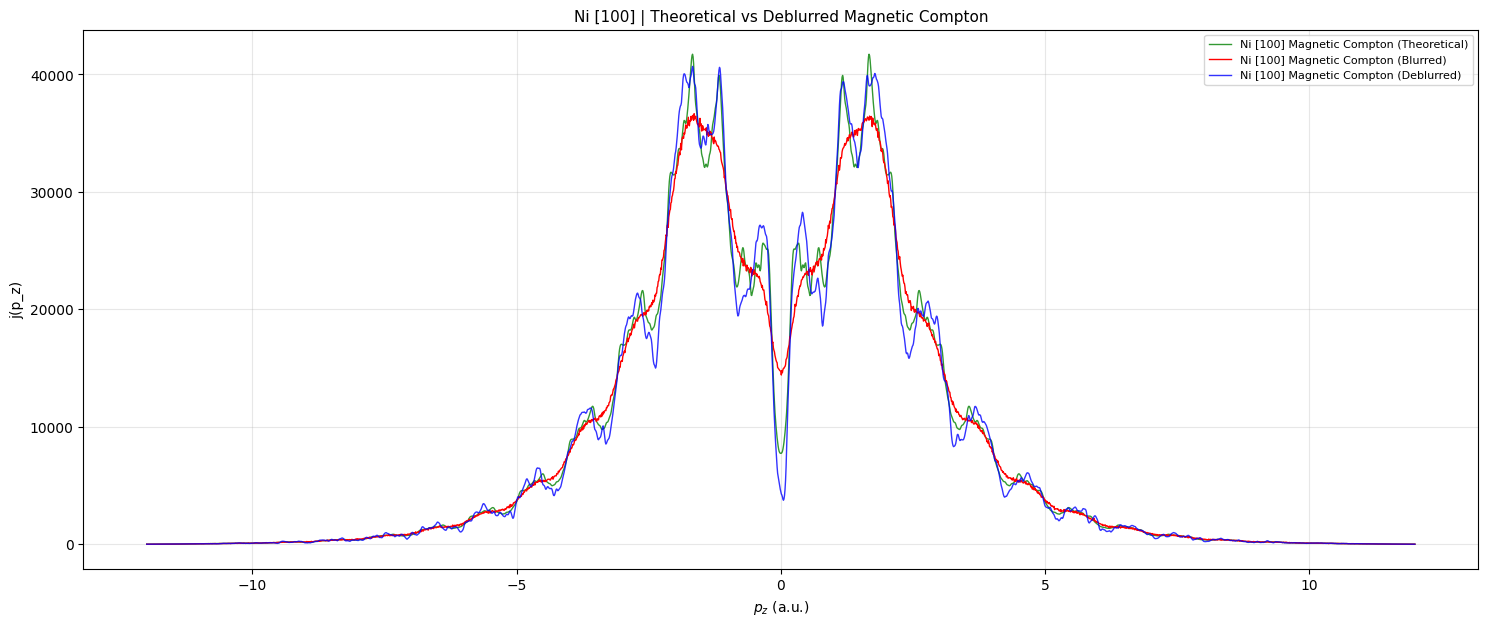

In [ ]:
blur_mcp_tensor = torch.FloatTensor(blur_mcp).unsqueeze(0)

final_model.eval()
with torch.no_grad():
    deblurred_mcp = final_model(blur_mcp_tensor).squeeze(0).numpy()

fig, ax = plt.subplots(figsize=(18, 7))
ax.plot(pz_mcp, mcp_scaled, 'g-', label='Ni [100] Magnetic Compton (Theoretical)', linewidth=1, alpha=0.8)
ax.plot(pz_mcp, blur_mcp, 'r-', label='Ni [100] Magnetic Compton (Blurred)', linewidth=1, alpha=1)
ax.plot(pz_mcp, deblurred_mcp, 'b-', label='Ni [100] Magnetic Compton (Deblurred)', linewidth=1, alpha=0.8)
ax.set_title('Ni [100] | Theoretical vs Deblurred Magnetic Compton', fontsize=11)
ax.set_xlabel('$p_z$ (a.u.)', fontsize=10)
ax.set_ylabel('j(p_z)', fontsize=10)
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)
fig.show()

print(deblurred_mcp.shape)
print(pz_mcp.shape)


error_estimate = np.sqrt(mcp_scaled)
red_chi, ssim_val = calculate_signal_metrics(mcp_scaled, deblurred_mcp, sigma=error_estimate)

print(f"Reduced Chi-Squared: {red_chi:.4f}")
print(f"SSIM: {ssim_val:.4f}")

repeated training but set to 90 epochs which is where best test loss occurs

Epoch [1/50], Train Loss: 3816508.3388889, Test Loss: 3760532.0000000
Epoch [2/50], Train Loss: 3783585.4333333, Test Loss: 3772073.2500000
Epoch [3/50], Train Loss: 3736775.4055556, Test Loss: 3728466.5000000
Epoch [4/50], Train Loss: 3672545.8870370, Test Loss: 3673901.0000000
Epoch [5/50], Train Loss: 3591962.0203704, Test Loss: 3540999.2500000
Epoch [6/50], Train Loss: 3493687.3518519, Test Loss: 3381984.2500000
Epoch [7/50], Train Loss: 3376547.6981481, Test Loss: 3312407.7500000
Epoch [8/50], Train Loss: 3248997.7500000, Test Loss: 3158201.5000000
Epoch [9/50], Train Loss: 3103657.0074074, Test Loss: 2985343.2500000
Epoch [10/50], Train Loss: 2953744.3759259, Test Loss: 2842469.2500000
Epoch [11/50], Train Loss: 2793169.6907407, Test Loss: 2599436.2500000
Epoch [12/50], Train Loss: 2622269.0833333, Test Loss: 2447746.0000000
Epoch [13/50], Train Loss: 2452612.5444444, Test Loss: 2396205.0000000
Epoch [14/50], Train Loss: 2279161.9074074, Test Loss: 2119091.5000000
Epoch [15/50], 

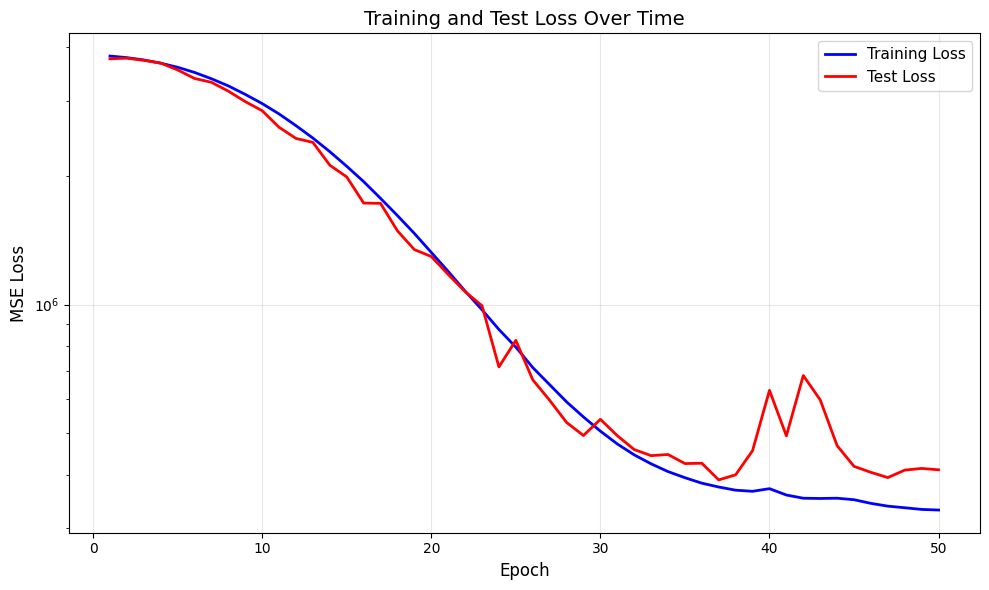


Final Training Loss: 330469.706713
Final Test Loss: 410471.656250


In [184]:
# Create the final model
u_net_model = AdaptedDeblurUNet()

# Use your existing function, but plug in the best learning rate from Optuna!
#best_lr = study.best_trial.params['lr']
best_lr = 0.005800640511713214

train_losses, test_losses = train_model(
    model=u_net_model,
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test,
    y_test=y_test, 
    epochs=50,       # Let it run long, early stopping (if in your train_model) will catch it
    batch_size=32, 
    lr=best_lr        # <--- Use the optimized learning rate here
)

visualise_training(train_losses, test_losses)

C:\Users\Jpjha\AppData\Local\Temp\ipykernel_9792\4148013040.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Jpjha\AppData\Local\Temp\ipykernel_9792\4148013040.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


(2401,)
(2401,)
Reduced Chi-Squared: 65118.8494
SSIM: 0.9349


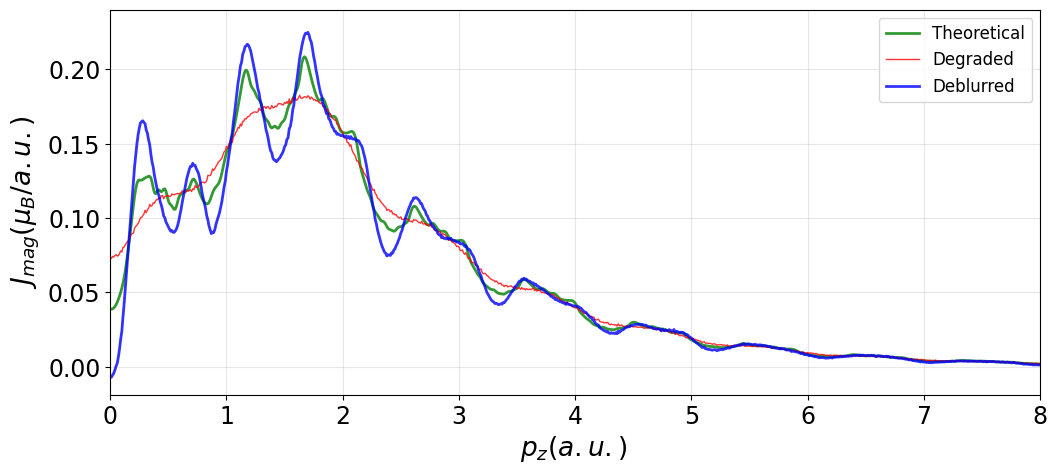

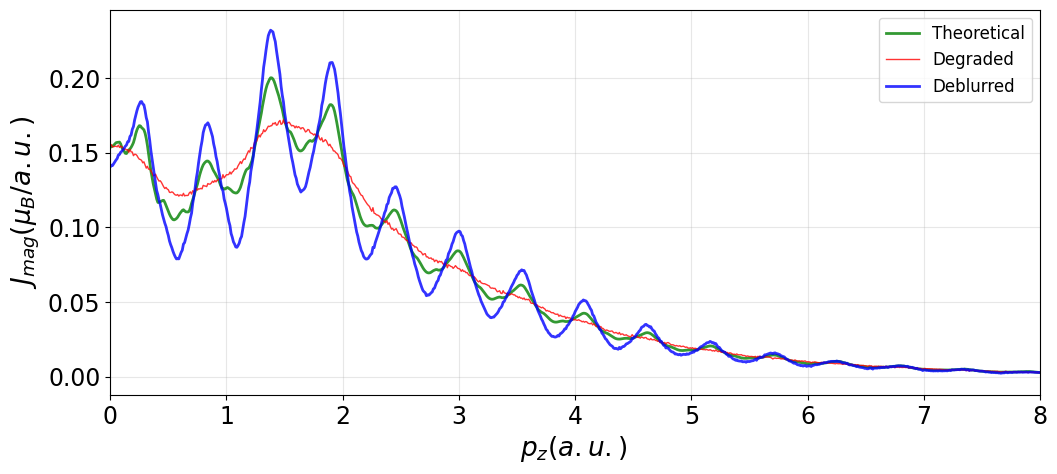

In [185]:
blur_mcp_100_tensor = torch.FloatTensor(blur_mcp_100).unsqueeze(0)
blur_mcp_111_tensor = torch.FloatTensor(blur_mcp_111).unsqueeze(0)

u_net_model.eval()
with torch.no_grad():
    deblurred_mcp_100 = u_net_model(blur_mcp_100_tensor).squeeze(0).numpy()
    deblurred_mcp_111 = u_net_model(blur_mcp_111_tensor).squeeze(0).numpy()

def rescale(y, t_count = 2e5):
    y = y / t_count
    return y

mcp_rescaled_100 = rescale(mcp_scaled_100)
mcp_rescaled_111 = rescale(mcp_scaled_111)
blur_mcp_100_rescaled = rescale(blur_mcp_100)
blur_mcp_111_rescaled = rescale(blur_mcp_111)
deblurred_mcp_100_rescaled = rescale(deblurred_mcp_100)
deblurred_mcp_111_rescaled = rescale(deblurred_mcp_111)


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pz_mcp, mcp_rescaled_100, '-', color = 'green', label='Theoretical', linewidth=2, alpha=0.8)
ax.plot(pz_mcp, blur_mcp_100_rescaled, '-', color = 'red', label='Degraded', linewidth=1, alpha=0.8)
ax.plot(pz_mcp, deblurred_mcp_100_rescaled, '-', color = 'blue', label='Deblurred', linewidth=2, alpha=0.8)
ax.set_xlabel('$p_z (a.u.)$ ', fontsize=19)
ax.set_ylabel('$J_{mag} (\mu_B / a.u.)$', fontsize=19)
ax.set_xlim(0, 8)
# ax.set_ylim(0, 50000)
# ax.set_yticks(np.linspace(0, 50000, 6))
# plt.ticklabel_format(axis='y', style='sci', scilimits=(4, 4), useMathText=True)
ax.tick_params(axis='both', which='major', labelsize=17)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)
fig.show()


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pz_mcp, mcp_rescaled_111, '-', color = 'green', label='Theoretical', linewidth=2, alpha=0.8)
ax.plot(pz_mcp, blur_mcp_111_rescaled, '-', color = 'red', label='Degraded', linewidth=1, alpha=0.8)
ax.plot(pz_mcp, deblurred_mcp_111_rescaled, '-', color = 'blue', label='Deblurred', linewidth=2, alpha=0.8)
ax.set_xlabel('$p_z (a.u.)$ ', fontsize=19)
ax.set_ylabel('$J_{mag} (\mu_B / a.u.)$', fontsize=19)
ax.set_xlim(0, 8)
# ax.set_ylim(0, 50000)
# ax.set_yticks(np.linspace(0, 50000, 6))
# plt.ticklabel_format(axis='y', style='sci', scilimits=(4, 4), useMathText=True)
ax.tick_params(axis='both', which='major', labelsize=17)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)
fig.show()

print(deblurred_mcp.shape)
print(pz_mcp.shape)


error_estimate = np.sqrt(mcp_scaled)
red_chi, ssim_val = calculate_signal_metrics(mcp_scaled, deblurred_mcp, sigma=error_estimate)

print(f"Reduced Chi-Squared: {red_chi:.4f}")
print(f"SSIM: {ssim_val:.4f}")

In [202]:
loss_100 = combined_loss(deblurred_mcp_100_rescaled, mcp_rescaled_100, alpha=1, beta=1e4, window_size=7)
loss_111 = combined_loss(deblurred_mcp_111_rescaled, mcp_rescaled_100, alpha=1, beta=1e4, window_size=7)
print(f'[100] plane combined loss: {loss_100}')
print(f'[111] plane combined loss: {loss_111}')

[100] plane combined loss: 0.06706687039300524
[111] plane combined loss: 0.1484906137060017


# CNN

In [53]:
# the CNN model for better deblurring performance
class DeblurCNN(nn.Module):
    def __init__(self):
        super(DeblurCNN, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.ReLU(),
        )
        
        self.decoder = nn.Sequential(
            nn.Conv1d(256, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(128, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(64, 1, kernel_size=7, padding=3),
        )
    
    def forward(self, x):
        # x shape: (batch_size, signal_length)
        x = x.unsqueeze(1)  
        x = self.encoder(x)
        x = self.decoder(x)
        return x.squeeze(1)  

Optimisation:

In [59]:

# Run the optimization
study = optuna.create_study(direction="minimize", study_name="CNN_Opt")
study.optimize(lambda trial: objective(trial, model=DeblurCNN(), max_epochs = 100), n_trials=30, show_progress_bar=True)

print("\nBest Hyperparameters:", study.best_trial.params)

[I 2026-04-02 11:10:49,885] A new study created in memory with name: CNN_Opt


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-02 12:01:26,048] Trial 0 finished with value: 2046700.03125 and parameters: {'lr': 1.005202836601685e-05, 'optimizer': 'AdamW', 'weight_decay': 0.00028720323917388895}. Best is trial 0 with value: 2046700.03125.
[I 2026-04-02 12:52:06,451] Trial 1 finished with value: 1941018.625 and parameters: {'lr': 0.0001705207336144543, 'optimizer': 'AdamW', 'weight_decay': 3.5430005670595365e-06}. Best is trial 1 with value: 1941018.625.
[I 2026-04-02 13:32:32,000] Trial 2 finished with value: 1996269.1875 and parameters: {'lr': 0.0014245337438726594, 'optimizer': 'AdamW', 'weight_decay': 0.0001808713677139994}. Best is trial 1 with value: 1941018.625.
[I 2026-04-02 14:21:23,948] Trial 3 finished with value: 1959815.21875 and parameters: {'lr': 7.920423443859305e-05, 'optimizer': 'Adam', 'weight_decay': 7.218257130474429e-06}. Best is trial 1 with value: 1941018.625.
[I 2026-04-02 15:10:44,651] Trial 4 finished with value: 1966754.53125 and parameters: {'lr': 0.0003434262404233767, 'op

Training:

Epoch [1/30], Train Loss: 57371569.1629630, Test Loss: 3955411.0000000
Epoch [2/30], Train Loss: 4499429.5000000, Test Loss: 4032398.2500000
Epoch [3/30], Train Loss: 3896004.8777778, Test Loss: 3898482.5000000
Epoch [4/30], Train Loss: 3870143.9500000, Test Loss: 3893156.7500000
Epoch [5/30], Train Loss: 3864008.6166667, Test Loss: 3877860.0000000
Epoch [6/30], Train Loss: 3845439.1870370, Test Loss: 3861914.7500000
Epoch [7/30], Train Loss: 3827960.4796296, Test Loss: 3842544.0000000
Epoch [8/30], Train Loss: 3806803.5851852, Test Loss: 3819356.7500000
Epoch [9/30], Train Loss: 3779096.3703704, Test Loss: 3780595.5000000
Epoch [10/30], Train Loss: 3730347.0444444, Test Loss: 3728067.0000000
Epoch [11/30], Train Loss: 3681411.0111111, Test Loss: 3677769.7500000
Epoch [12/30], Train Loss: 3621990.8870370, Test Loss: 3613388.2500000
Epoch [13/30], Train Loss: 3546251.2537037, Test Loss: 3519708.5000000
Epoch [14/30], Train Loss: 3536604.5500000, Test Loss: 3496601.0000000
Epoch [15/30],

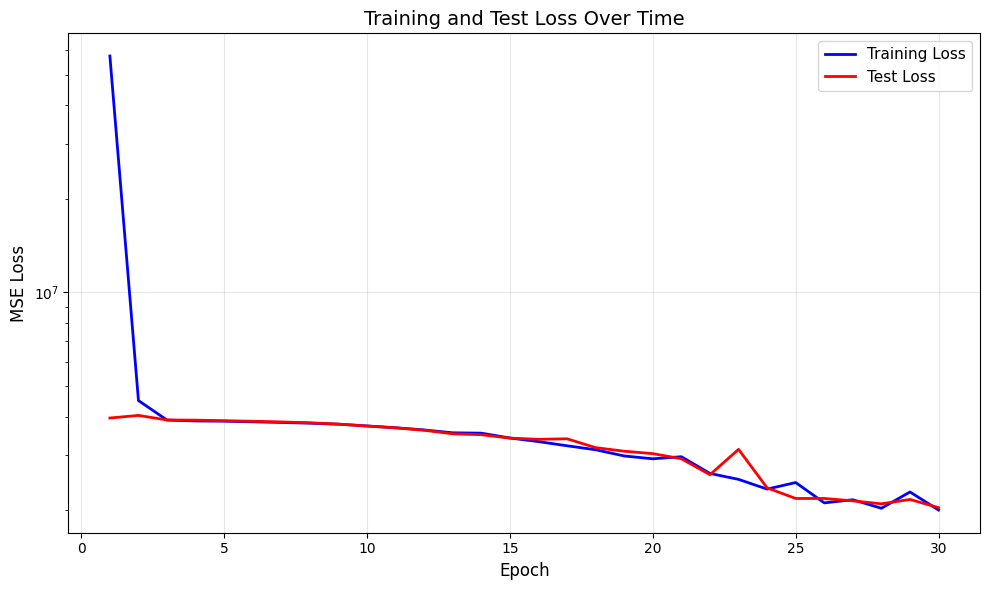


Final Training Loss: 2004400.091667
Final Test Loss: 2039994.250000
Reduced Chi-Squared: 603.9413
SSIM: 0.9321


C:\Users\Jpjha\AppData\Local\Temp\ipykernel_9792\2164024769.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Jpjha\AppData\Local\Temp\ipykernel_9792\2164024769.py:63: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


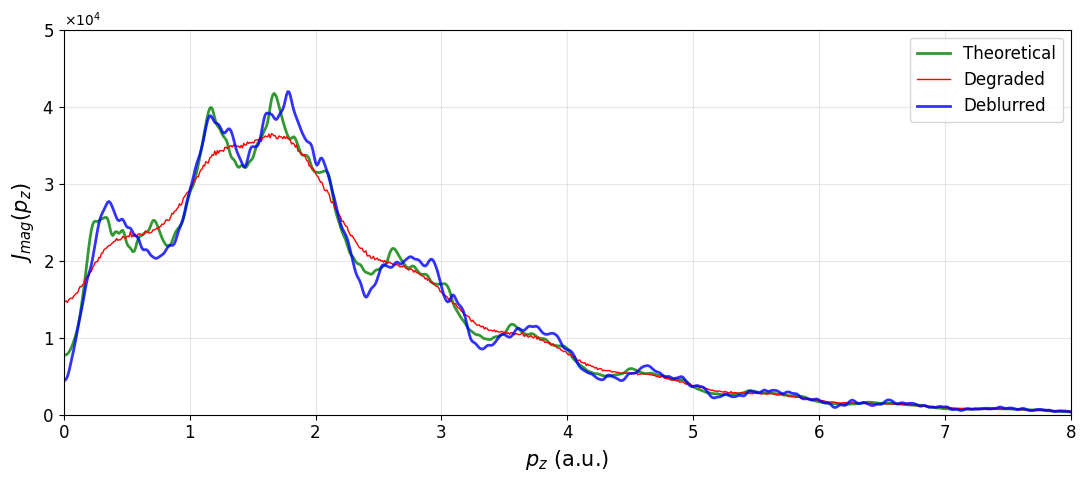

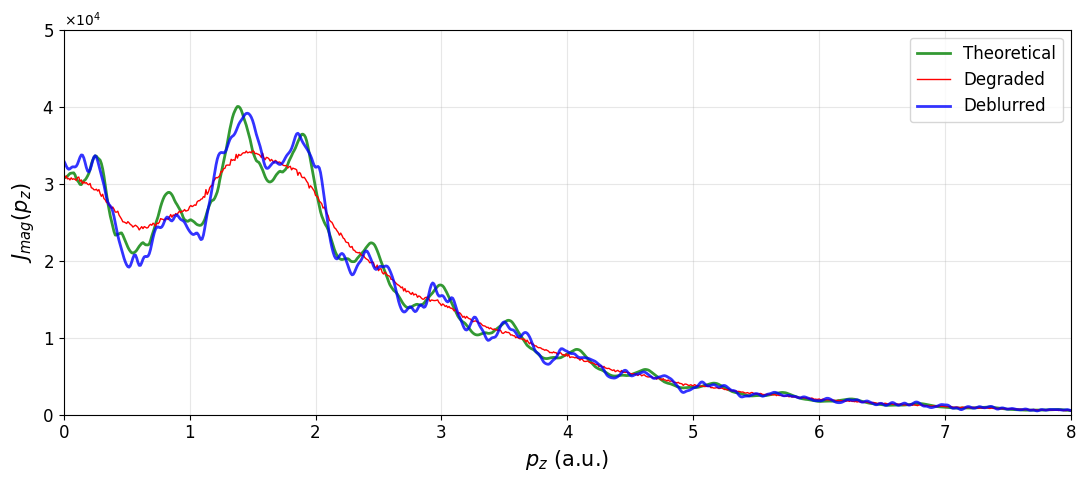

In [125]:
# Create the final model
CNN_model = DeblurCNN()

#manually save best lr from above to prevent overwriting 
best_lr = 0.0001705207336144543

# Use your existing function, but plug in the best learning rate from Optuna!
#best_lr = study.best_trial.params['lr']

train_losses, test_losses = train_model(
    model=CNN_model,
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test,
    y_test=y_test, 
    epochs=30,       # Let it run long, early stopping (if in your train_model) will catch it
    batch_size=32, 
    lr=best_lr        # <--- Use the optimized learning rate here
)

visualise_training(train_losses, test_losses)

blur_mcp_100_tensor = torch.FloatTensor(blur_mcp_100).unsqueeze(0)
blur_mcp_111_tensor = torch.FloatTensor(blur_mcp_111).unsqueeze(0)

CNN_model.eval()
with torch.no_grad():
    deblurred_mcp_100 = CNN_model(blur_mcp_100_tensor).squeeze(0).numpy()
    deblurred_mcp_111 = CNN_model(blur_mcp_111_tensor).squeeze(0).numpy()



fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(pz_mcp, mcp_scaled_100, 'g-', label='Theoretical', linewidth=2, alpha=0.8)
ax.plot(pz_mcp, blur_mcp_100, 'r-', label='Degraded', linewidth=1, alpha=1)
ax.plot(pz_mcp, deblurred_mcp_100, 'b-', label='Deblurred', linewidth=2, alpha=0.8)
ax.set_xlabel('$p_z$ (a.u.)', fontsize=15)
ax.set_ylabel('$J_{mag}(p_z)$', fontsize=15)
ax.set_xlim(0, 8)
ax.set_ylim(0, 50000)
ax.set_yticks(np.linspace(0, 50000, 6))
plt.ticklabel_format(axis='y', style='sci', scilimits=(4, 4), useMathText=True)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)
fig.show()



fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(pz_mcp, mcp_scaled_111, 'g-', label='Theoretical', linewidth=2, alpha=0.8)
ax.plot(pz_mcp, blur_mcp_111, 'r-', label='Degraded', linewidth=1, alpha=1)
ax.plot(pz_mcp, deblurred_mcp_111, 'b-', label='Deblurred', linewidth=2, alpha=0.8)
ax.set_xlabel('$p_z$ (a.u.)', fontsize=15)
ax.set_ylabel('$J_{mag}(p_z)$', fontsize=15)
ax.set_xlim(0, 8)
ax.set_ylim(0, 50000)
ax.set_yticks(np.linspace(0, 50000, 6))
plt.ticklabel_format(axis='y', style='sci', scilimits=(4, 4), useMathText=True)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)
fig.show()


error_estimate = np.sqrt(mcp_scaled_111)
red_chi, ssim_val = calculate_signal_metrics(mcp_scaled_111, deblurred_mcp_111, sigma=error_estimate)

print(f"Reduced Chi-Squared: {red_chi:.4f}")
print(f"SSIM: {ssim_val:.4f}")

C:\Users\Jpjha\AppData\Local\Temp\ipykernel_9792\3737589851.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Jpjha\AppData\Local\Temp\ipykernel_9792\3737589851.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


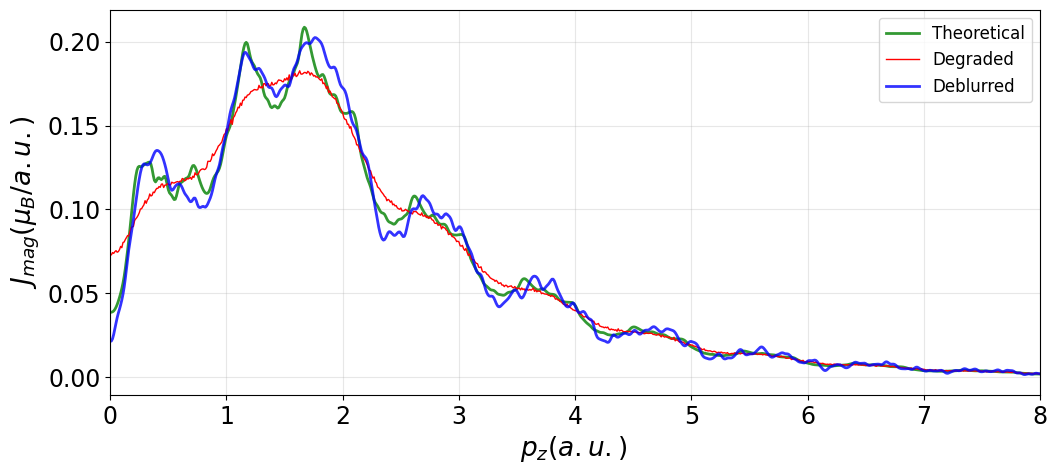

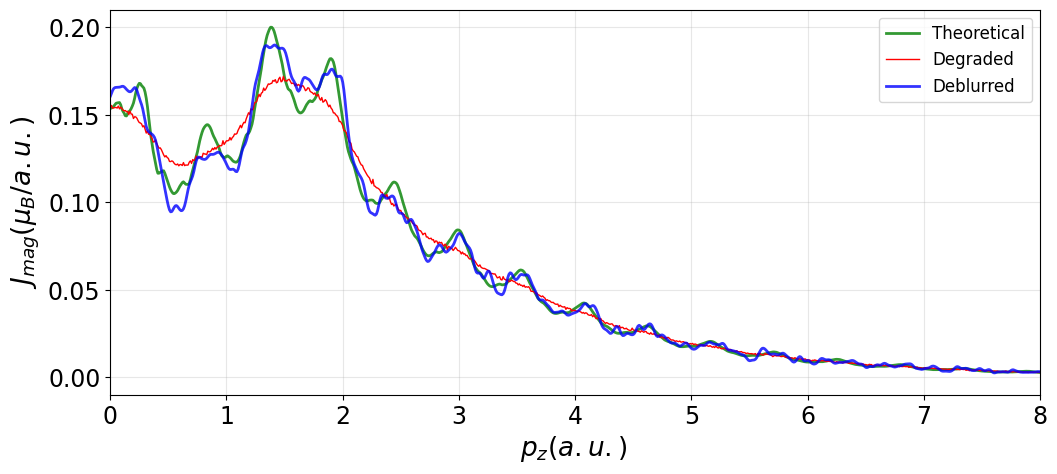

In [197]:
blur_mcp_100_tensor = torch.FloatTensor(blur_mcp_100).unsqueeze(0)
blur_mcp_111_tensor = torch.FloatTensor(blur_mcp_111).unsqueeze(0)

CNN_model.eval()
with torch.no_grad():
    deblurred_mcp_100 = CNN_model(blur_mcp_100_tensor).squeeze(0).numpy()
    deblurred_mcp_111 = CNN_model(blur_mcp_111_tensor).squeeze(0).numpy()

def rescale(y, t_count = 2e5):
    y = y / t_count
    return y

mcp_rescaled_100 = rescale(mcp_scaled_100)
mcp_rescaled_111 = rescale(mcp_scaled_111)
blur_mcp_100_rescaled = rescale(blur_mcp_100)
blur_mcp_111_rescaled = rescale(blur_mcp_111)
deblurred_mcp_100_rescaled = rescale(deblurred_mcp_100)
deblurred_mcp_111_rescaled = rescale(deblurred_mcp_111)


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pz_mcp, mcp_rescaled_100, 'g-', label='Theoretical', linewidth=2, alpha=0.8)
ax.plot(pz_mcp, blur_mcp_100_rescaled, 'r-', label='Degraded', linewidth=1, alpha=1)
ax.plot(pz_mcp, deblurred_mcp_100_rescaled, 'b-', label='Deblurred', linewidth=2, alpha=0.8)
ax.set_xlabel('$p_z (a.u.)$ ', fontsize=19)
ax.set_ylabel('$J_{mag} (\mu_B / a.u.)$', fontsize=19)
ax.set_xlim(0, 8)
# ax.set_ylim(0, 50000)
# ax.set_yticks(np.linspace(0, 50000, 6))
# plt.ticklabel_format(axis='y', style='sci', scilimits=(4, 4), useMathText=True)
ax.tick_params(axis='both', which='major', labelsize=17)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)
fig.show()



fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pz_mcp, mcp_rescaled_111, 'g-', label='Theoretical', linewidth=2, alpha=0.8)
ax.plot(pz_mcp, blur_mcp_111_rescaled, 'r-', label='Degraded', linewidth=1, alpha=1)
ax.plot(pz_mcp, deblurred_mcp_111_rescaled, 'b-', label='Deblurred', linewidth=2, alpha=0.8)
ax.set_xlabel('$p_z (a.u.)$ ', fontsize=19)
ax.set_ylabel('$J_{mag} (\mu_B / a.u.)$', fontsize=19)
ax.set_xlim(0, 8)
# ax.set_ylim(0, 50000)
# ax.set_yticks(np.linspace(0, 50000, 6))
#plt.ticklabel_format(axis='y', style='sci', scilimits=(4, 4), useMathText=True)
ax.tick_params(axis='both', which='major', labelsize=17)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)
fig.show()

In [201]:
loss_1001 = combined_loss(deblurred_mcp_100_rescaled, mcp_rescaled_100, alpha=1, beta=1e5, window_size=7)
loss_1002 = combined_loss(deblurred_mcp_100_rescaled, mcp_rescaled_100, alpha=1, beta=1e4, window_size=7)
loss_1003 = combined_loss(deblurred_mcp_100_rescaled, mcp_rescaled_100, alpha=1, beta=1e3, window_size=7)
loss_111 = combined_loss(deblurred_mcp_111_rescaled, mcp_rescaled_111, alpha=1, beta=1e4, window_size=7)

print(f'[100] plane combined loss: {loss_1001}')
print(f'[100] plane combined loss: {loss_1002}')
print(f'[100] plane combined loss: {loss_1003}')
print(f'[111] plane combined loss: {loss_111}')

[100] plane combined loss: 0.16193244181699185
[100] plane combined loss: 0.06706687039300524
[100] plane combined loss: 0.05758031325060658
[111] plane combined loss: 0.07213323852057212


In [ ]:
1